In [ ]:
# ==========================================
# 서울시 경계 GeoJSON
# WGS84(CRS84) → UTM-K(EPSG:5179) 변환
# ==========================================

import geopandas as gpd
from google.colab import files

# 1. GeoJSON 파일 업로드
uploaded = files.upload()

# 2. 업로드한 파일명 지정
input_file = "서울_자치구_경계_2017.geojson"

# 3. GeoJSON 읽기
gdf = gpd.read_file(input_file)

# 4. 원본 데이터 확인
print("===== 원본 데이터 =====")
print("CRS:", gdf.crs)
print("컬럼:", gdf.columns.tolist())
print("객체 수:", len(gdf))
print("좌표 범위:", gdf.total_bounds)

# 5. 원본 CRS를 EPSG:4326으로 명시
# 현재 파일은 CRS84이며 좌표가 경도/위도 순서이므로
# GeoPandas 공간변환에서는 EPSG:4326으로 처리
gdf = gdf.set_crs(epsg=4326, allow_override=True)

# 6. EPSG:5179 (UTM-K)로 좌표 변환
gdf_5179 = gdf.to_crs(epsg=5179)

# 7. 변환 결과 확인
print("\n===== 변환 결과 =====")
print("CRS:", gdf_5179.crs)
print("좌표 범위:", gdf_5179.total_bounds)

# 자치구 정보 확인
print(gdf_5179[
    ["SIG_CD", "SIG_KOR_NM", "SIG_ENG_NM"]
].head())

# 8. GeoJSON으로 저장
output_file = "서울_자치구_경계_2017_EPSG5179.geojson"

gdf_5179.to_file(
    output_file,
    driver="GeoJSON",
    encoding="utf-8"
)

# 9. 변환 파일 다운로드
files.download(output_file)

Saving 서울_자치구_경계_2017.geojson to 서울_자치구_경계_2017.geojson
===== 원본 데이터 =====
CRS: EPSG:4326
컬럼: ['SIG_CD', 'SIG_ENG_NM', 'SIG_KOR_NM', 'geometry']
객체 수: 25
좌표 범위: [126.76448396  37.42829748 127.18379493  37.70145528]

===== 변환 결과 =====
CRS: EPSG:5179
좌표 범위: [ 935035.25474567 1936665.54807067  972067.56886318 1966987.15818902]
  SIG_CD SIG_KOR_NM    SIG_ENG_NM
0  11110        종로구     Jongno-gu
1  11140         중구       Jung-gu
2  11170        용산구    Yongsan-gu
3  11200        성동구  Seongdong-gu
4  11215        광진구   Gwangjin-gu


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. GeoJSON 파일 업로드
uploaded = files.upload()

# 2. 업로드한 파일명 지정
input_file = "서울_행정동_경계_2017.geojson"

# 3. GeoJSON 읽기
gdf = gpd.read_file(input_file)

# 4. 원본 데이터 확인
print("===== 원본 데이터 =====")
print("CRS:", gdf.crs)
print("컬럼:", gdf.columns.tolist())
print("객체 수:", len(gdf))
print("좌표 범위:", gdf.total_bounds)

# 5. 원본 CRS를 EPSG:4326으로 명시
# 현재 파일은 CRS84이며 좌표가 경도/위도 순서이므로
# GeoPandas 공간변환에서는 EPSG:4326으로 처리
gdf = gdf.set_crs(epsg=4326, allow_override=True)

# 6. EPSG:5179 (UTM-K)로 좌표 변환
gdf_5179 = gdf.to_crs(epsg=5179)

# 7. 변환 결과 확인
print("\n===== 변환 결과 =====")
print("CRS:", gdf_5179.crs)
print("좌표 범위:", gdf_5179.total_bounds)

# 자치구 정보 확인
print(gdf_5179[
    ['adm_cd', 'adm_nm', 'geometry']
].head())

# 8. GeoJSON으로 저장
output_file = "서울_행정동_경계_2017_EPSG5179.geojson"

gdf_5179.to_file(
    output_file,
    driver="GeoJSON",
    encoding="utf-8"
)

# 9. 변환 파일 다운로드
files.download(output_file)

Saving 서울_행정동_경계_2017.geojson to 서울_행정동_경계_2017 (1).geojson
===== 원본 데이터 =====
CRS: EPSG:4326
컬럼: ['adm_cd', 'adm_nm', 'geometry']
객체 수: 424
좌표 범위: [126.7642783  37.4290107 127.1835519  37.7010799]

===== 변환 결과 =====
CRS: EPSG:5179
좌표 범위: [ 935017.063      1936739.14960002  972046.1953     1966943.62550001]
    adm_cd         adm_nm                                           geometry
0  1101053  서울특별시 종로구 사직동  POLYGON ((953808.688 1953047.862, 953817.563 1...
1  1101054  서울특별시 종로구 삼청동  POLYGON ((954332.749 1955199.002, 954392.625 1...
2  1101055  서울특별시 종로구 부암동  POLYGON ((953730.004 1955368.624, 953528.119 1...
3  1101056  서울특별시 종로구 평창동  POLYGON ((953683.063 1959232.375, 953806.75 19...
4  1101057  서울특별시 종로구 무악동  POLYGON ((952380.125 1953627, 952567.946 19534...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import pandas as pd
import geopandas as gpd
from google.colab import drive

drive.mount('/content/drive')

# 1. 유동인구 데이터
file_path = "/content/drive/MyDrive/새싹 교육과정/최종프로젝트(2026.09.~10)/이환희/좌표계 변환 코딩/flow_age_pop_202507.csv"

df = pd.read_csv(file_path)

df.head()

# 불필요한 CSV index 컬럼 제거
df = df.drop(columns=["Unnamed: 0"], errors="ignore")


# 2. X/Y → Point
flow_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["X_COORD"],
        df["Y_COORD"]
    ),
    crs="EPSG:5179"
)


# 3. 행정동 경계
dong_gdf = gpd.read_file(
    "서울_행정동_경계_2017_EPSG5179.geojson"
)

# 좌표계 확인
print(flow_gdf.crs)
print(dong_gdf.crs)


# 4. 공간조인
result = gpd.sjoin(
    flow_gdf,
    dong_gdf[
        ["adm_cd", "adm_nm", "geometry"]
    ],
    how="left",
    predicate="within"
)


# 5. 결과 확인
print(
    result[
        [
            "STD_YM",
            "BLOCK_CD",
            "X_COORD",
            "Y_COORD",
            "adm_cd",
            "adm_nm"
        ]
    ].head()
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
EPSG:5179
EPSG:5179
   STD_YM              BLOCK_CD        X_COORD       Y_COORD   adm_cd  \
0  202507  11230510101020000001  956633.991787  1.947479e+06  1122055   
1  202507  11230510101020000001  956683.991787  1.947429e+06  1122055   
2  202507  11230510101020000001  956683.991787  1.947479e+06  1122055   
3  202507  11230510101020000001  956683.991787  1.947579e+06  1103074   
4  202507  11230510101020000001  956733.991787  1.947379e+06  1122055   

          adm_nm  
0  서울특별시 서초구 잠원동  
1  서울특별시 서초구 잠원동  
2  서울특별시 서초구 잠원동  
3  서울특별시 용산구 한남동  
4  서울특별시 서초구 잠원동  


In [15]:
import pandas as pd
import geopandas as gpd
from google.colab import files
import os
import glob
import shutil

# ==========================================
# 1. 결과 폴더 초기화
# ==========================================

output_dir = "converted_wgs84"

# 이전 실행 결과가 있으면 삭제
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

# 빈 폴더 새로 생성
os.makedirs(output_dir)


# ==========================================
# 2. 이번에 처리할 CSV 파일 업로드
# ==========================================

uploaded = files.upload()

# 이번에 업로드한 파일만 가져오기
csv_files = [
    filename
    for filename in uploaded.keys()
    if filename.lower().endswith(".csv")
]

print(f"\n이번 변환 대상: {len(csv_files)}개")

for filename in csv_files:
    print(" -", filename)


# ==========================================
# 3. 각 CSV 반복 처리
# ==========================================

for file_path in csv_files:

    print(f"\n처리 중: {file_path}")

    df = pd.read_csv(file_path)

    # 좌표 컬럼 확인
    if "X_COORD" not in df.columns or "Y_COORD" not in df.columns:
        print("→ X_COORD 또는 Y_COORD가 없어 건너뜁니다.")
        continue

    # EPSG:5179 Point 생성
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(
            df["X_COORD"],
            df["Y_COORD"]
        ),
        crs="EPSG:5179"
    )

    # EPSG:5179 → EPSG:4326
    gdf_4326 = gdf.to_crs(epsg=4326)

    # 위도/경도 추가
    df["longitude"] = gdf_4326.geometry.x
    df["latitude"] = gdf_4326.geometry.y

    # 출력 파일명
    base_name = os.path.splitext(
        os.path.basename(file_path)
    )[0]

    output_file = os.path.join(
        output_dir,
        f"{base_name}_wgs84.csv"
    )

    # CSV 저장
    df.to_csv(
        output_file,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"→ 변환 완료: {output_file}")


# ==========================================
# 4. 이번 실행 결과만 ZIP 압축
# ==========================================

zip_file = "converted_wgs84.zip"

# 이전 ZIP 파일이 있으면 삭제
if os.path.exists(zip_file):
    os.remove(zip_file)

shutil.make_archive(
    "converted_wgs84",
    "zip",
    output_dir
)

print("\n===== 전체 변환 완료 =====")
print("ZIP 파일:", zip_file)


# ==========================================
# 5. ZIP 다운로드
# ==========================================

files.download(zip_file)

Saving flow_wkdy_pop_202507.csv to flow_wkdy_pop_202507.csv
Saving flow_wkdy_pop_202508.csv to flow_wkdy_pop_202508.csv
Saving flow_wkdy_pop_202509.csv to flow_wkdy_pop_202509.csv
Saving flow_wkdy_pop_202510.csv to flow_wkdy_pop_202510.csv
Saving flow_wkdy_pop_202511.csv to flow_wkdy_pop_202511.csv
Saving flow_wkdy_pop_202512.csv to flow_wkdy_pop_202512.csv

이번 변환 대상: 6개
 - flow_wkdy_pop_202507.csv
 - flow_wkdy_pop_202508.csv
 - flow_wkdy_pop_202509.csv
 - flow_wkdy_pop_202510.csv
 - flow_wkdy_pop_202511.csv
 - flow_wkdy_pop_202512.csv

처리 중: flow_wkdy_pop_202507.csv
→ 변환 완료: converted_wgs84/flow_wkdy_pop_202507_wgs84.csv

처리 중: flow_wkdy_pop_202508.csv
→ 변환 완료: converted_wgs84/flow_wkdy_pop_202508_wgs84.csv

처리 중: flow_wkdy_pop_202509.csv
→ 변환 완료: converted_wgs84/flow_wkdy_pop_202509_wgs84.csv

처리 중: flow_wkdy_pop_202510.csv
→ 변환 완료: converted_wgs84/flow_wkdy_pop_202510_wgs84.csv

처리 중: flow_wkdy_pop_202511.csv
→ 변환 완료: converted_wgs84/flow_wkdy_pop_202511_wgs84.csv

처리 중: flow_wkdy_p

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
import pandas as pd
import geopandas as gpd
import os
import shutil

from google.colab import files

# 파일 업로드
uploaded = files.upload()

Saving flow_age_pop_202507_wgs84.csv to flow_age_pop_202507_wgs84 (1).csv
Saving flow_time_pop_202507_wgs84.csv to flow_time_pop_202507_wgs84.csv
Saving flow_wkdy_pop_202507_wgs84.csv to flow_wkdy_pop_202507_wgs84.csv
Saving 서울_행정동_경계_2017_EPSG5179.geojson to 서울_행정동_경계_2017_EPSG5179 (1).geojson


In [17]:
dong_file = "서울_행정동_경계_2017.geojson"

dong_gdf = gpd.read_file(dong_file)

print(dong_gdf.crs)
print(dong_gdf.columns)
print(dong_gdf.head())

EPSG:4326
Index(['adm_cd', 'adm_nm', 'geometry'], dtype='object')
    adm_cd         adm_nm                                           geometry
0  1101053  서울특별시 종로구 사직동  POLYGON ((126.97689 37.57565, 126.97703 37.569...
1  1101054  서울특별시 종로구 삼청동  POLYGON ((126.98269 37.59507, 126.98337 37.594...
2  1101055  서울특별시 종로구 부암동  POLYGON ((126.97585 37.59656, 126.97359 37.593...
3  1101056  서울특별시 종로구 평창동  POLYGON ((126.97507 37.63139, 126.97649 37.630...
4  1101057  서울특별시 종로구 무악동  POLYGON ((126.96067 37.5808, 126.96281 37.5794...


In [18]:
output_dir = "seoul_flow_population"

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

os.makedirs(output_dir)

In [19]:
flow_files = [
    "flow_age_pop_202507_wgs84.csv",
    "flow_time_pop_202507_wgs84.csv",
    "flow_wkdy_pop_202507_wgs84.csv"
]

for file_name in flow_files:

    print(f"\n처리 시작: {file_name}")

    # CSV 불러오기
    df = pd.read_csv(file_name)

    # longitude / latitude → Point geometry
    flow_gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(
            df["longitude"],
            df["latitude"]
        ),
        crs="EPSG:4326"
    )

    # 행정동 경계와 공간조인
    joined = gpd.sjoin(
        flow_gdf,
        dong_gdf[["adm_cd", "adm_nm", "geometry"]],
        how="left",
        predicate="within"
    )

    # 서울 행정동에 포함된 데이터만 추출
    seoul = joined[
        joined["adm_cd"].notna()
    ].copy()

    # 공간조인 과정에서 생긴 불필요한 컬럼 제거
    seoul = seoul.drop(
        columns=["geometry", "index_right"],
        errors="ignore"
    )

    # 저장 파일명
    base_name = os.path.splitext(file_name)[0]

    output_file = os.path.join(
        output_dir,
        f"{base_name}_seoul.csv"
    )

    seoul.to_csv(
        output_file,
        index=False,
        encoding="utf-8-sig"
    )

    # 결과 확인
    print(f"전체 데이터 : {len(df):,}")
    print(f"서울 데이터 : {len(seoul):,}")
    print(f"서울 외부    : {len(df) - len(seoul):,}")
    print(f"저장 완료    : {output_file}")


처리 시작: flow_age_pop_202507_wgs84.csv
전체 데이터 : 98,129
서울 데이터 : 15,206
서울 외부    : 82,923
저장 완료    : seoul_flow_population/flow_age_pop_202507_wgs84_seoul.csv

처리 시작: flow_time_pop_202507_wgs84.csv
전체 데이터 : 94,099
서울 데이터 : 15,207
서울 외부    : 78,892
저장 완료    : seoul_flow_population/flow_time_pop_202507_wgs84_seoul.csv

처리 시작: flow_wkdy_pop_202507_wgs84.csv
전체 데이터 : 117,825
서울 데이터 : 15,325
서울 외부    : 102,500
저장 완료    : seoul_flow_population/flow_wkdy_pop_202507_wgs84_seoul.csv


In [20]:
print("===== 세 파일 행정동 매칭 검증 =====")

for file_name in flow_files:

    base_name = os.path.splitext(file_name)[0]

    result_file = os.path.join(
        output_dir,
        f"{base_name}_seoul.csv"
    )

    df_check = pd.read_csv(result_file)

    print("\n----------------------------------")
    print(f"파일: {file_name}")
    print("----------------------------------")

    # 행 수
    print(f"서울 데이터 수: {len(df_check):,}")

    # 행정동 개수
    print(
        f"매칭된 행정동 수: "
        f"{df_check['adm_cd'].nunique():,}"
    )

    # 행정동 결측값
    print(
        f"adm_cd 결측: "
        f"{df_check['adm_cd'].isna().sum():,}"
    )

    print(
        f"adm_nm 결측: "
        f"{df_check['adm_nm'].isna().sum():,}"
    )

    # 좌표 범위
    print(
        "경도 범위:",
        df_check["longitude"].min(),
        "~",
        df_check["longitude"].max()
    )

    print(
        "위도 범위:",
        df_check["latitude"].min(),
        "~",
        df_check["latitude"].max()
    )

    # 일부 데이터 확인
    print("\n샘플:")
    print(
        df_check[
            ["longitude", "latitude", "adm_cd", "adm_nm"]
        ].head()
    )

===== 세 파일 행정동 매칭 검증 =====

----------------------------------
파일: flow_age_pop_202507_wgs84.csv
----------------------------------
서울 데이터 수: 15,206
매칭된 행정동 수: 37
adm_cd 결측: 0
adm_nm 결측: 0
경도 범위: 127.00921319446844 ~ 127.12381400349172
위도 범위: 37.45831923778749 ~ 37.53563365834271

샘플:
    longitude   latitude   adm_cd         adm_nm
0  127.009213  37.525596  1122055  서울특별시 서초구 잠원동
1  127.009782  37.525148  1122055  서울특별시 서초구 잠원동
2  127.009779  37.525598  1122055  서울특별시 서초구 잠원동
3  127.009773  37.526500  1103074  서울특별시 용산구 한남동
4  127.010351  37.524699  1122055  서울특별시 서초구 잠원동

----------------------------------
파일: flow_time_pop_202507_wgs84.csv
----------------------------------
서울 데이터 수: 15,207
매칭된 행정동 수: 37
adm_cd 결측: 0
adm_nm 결측: 0
경도 범위: 127.00921319446844 ~ 127.12381400349172
위도 범위: 37.45831923778749 ~ 37.53563365834271

샘플:
    longitude   latitude   adm_cd         adm_nm
0  127.009213  37.525596  1122055  서울특별시 서초구 잠원동
1  127.009782  37.525148  1122055  서울특별시 서초구 잠원동
2  127.009779

In [21]:
age_file = os.path.join(
    output_dir,
    "flow_age_pop_202507_wgs84_seoul.csv"
)

age_check = pd.read_csv(age_file)

# 행정동별 고유 목록
dong_list = (
    age_check[["adm_cd", "adm_nm"]]
    .drop_duplicates()
    .sort_values("adm_nm")
    .reset_index(drop=True)
)

# 자치구 추출
dong_list["자치구"] = (
    dong_list["adm_nm"]
    .str.split()
    .str[1]
)

print("===== 포함된 행정동 =====")
print(dong_list.to_string(index=False))

print("\n===== 자치구별 행정동 수 =====")
print(
    dong_list
    .groupby("자치구")["adm_cd"]
    .nunique()
    .sort_values(ascending=False)
)

===== 포함된 행정동 =====
 adm_cd           adm_nm 자치구
1123068   서울특별시 강남구 개포1동 강남구
1123080   서울특별시 강남구 개포2동 강남구
1123071   서울특별시 강남구 개포4동 강남구
1123052   서울특별시 강남구 논현1동 강남구
1123053   서울특별시 강남구 논현2동 강남구
1123060   서울특별시 강남구 대치1동 강남구
1123079   서울특별시 강남구 대치2동 강남구
1123063   서울특별시 강남구 대치4동 강남구
1123066   서울특별시 강남구 도곡1동 강남구
1123067   서울특별시 강남구 도곡2동 강남구
1123058   서울특별시 강남구 삼성1동 강남구
1123059   서울특별시 강남구 삼성2동 강남구
1123076    서울특별시 강남구 세곡동 강남구
1123075    서울특별시 강남구 수서동 강남구
1123051    서울특별시 강남구 신사동 강남구
1123077   서울특별시 강남구 압구정동 강남구
1123064   서울특별시 강남구 역삼1동 강남구
1123065   서울특별시 강남구 역삼2동 강남구
1123073   서울특별시 강남구 일원1동 강남구
1123074   서울특별시 강남구 일원2동 강남구
1123072   서울특별시 강남구 일원본동 강남구
1123078    서울특별시 강남구 청담동 강남구
1122068    서울특별시 서초구 내곡동 서초구
1122052   서울특별시 서초구 서초2동 서초구
1122054   서울특별시 서초구 서초4동 서초구
1122066   서울특별시 서초구 양재1동 서초구
1122067   서울특별시 서초구 양재2동 서초구
1122055    서울특별시 서초구 잠원동 서초구
1104065 서울특별시 성동구 성수1가1동 성동구
1104073    서울특별시 성동구 옥수동 성동구
1124066   서울특별시 송파구 가락1동 송파구
1124069   서울특별시 송파구 문정2동 송파구
1124064    서울특별시 송파구 삼전

In [22]:
# ==========================================
# 강남구 데이터만 추출
# ==========================================

gangnam_output_dir = "gangnam_flow_population"

if os.path.exists(gangnam_output_dir):
    shutil.rmtree(gangnam_output_dir)

os.makedirs(gangnam_output_dir)


for file_name in flow_files:

    base_name = os.path.splitext(file_name)[0]

    # 앞에서 생성한 서울 데이터
    seoul_file = os.path.join(
        output_dir,
        f"{base_name}_seoul.csv"
    )

    df = pd.read_csv(seoul_file)

    # 강남구 데이터만 선택
    gangnam = df[
        df["adm_nm"].str.contains(
            "서울특별시 강남구",
            na=False
        )
    ].copy()

    # 저장
    output_file = os.path.join(
        gangnam_output_dir,
        f"{base_name}_gangnam.csv"
    )

    gangnam.to_csv(
        output_file,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n------------------------------")
    print(file_name)
    print("------------------------------")
    print(f"서울 전체 매칭 : {len(df):,}")
    print(f"강남구 데이터 : {len(gangnam):,}")
    print(
        f"강남구 행정동 : "
        f"{gangnam['adm_cd'].nunique()}개"
    )


------------------------------
flow_age_pop_202507_wgs84.csv
------------------------------
서울 전체 매칭 : 15,206
강남구 데이터 : 14,746
강남구 행정동 : 22개

------------------------------
flow_time_pop_202507_wgs84.csv
------------------------------
서울 전체 매칭 : 15,207
강남구 데이터 : 14,746
강남구 행정동 : 22개

------------------------------
flow_wkdy_pop_202507_wgs84.csv
------------------------------
서울 전체 매칭 : 15,325
강남구 데이터 : 14,837
강남구 행정동 : 22개


In [23]:
import pandas as pd
import os

files_check = [
    "flow_age_pop_202507_wgs84",
    "flow_time_pop_202507_wgs84",
    "flow_wkdy_pop_202507_wgs84"
]

for base_name in files_check:

    file_path = os.path.join(
        gangnam_output_dir,
        f"{base_name}_gangnam.csv"
    )

    df = pd.read_csv(file_path)

    unique_coords = (
        df[["longitude", "latitude"]]
        .drop_duplicates()
    )

    print("\n------------------------------")
    print(base_name)
    print("------------------------------")
    print(f"전체 행 수       : {len(df):,}")
    print(f"고유 좌표 수     : {len(unique_coords):,}")
    print(f"고유 BLOCK_CD 수 : {df['BLOCK_CD'].nunique():,}")
    print(f"행정동 수        : {df['adm_cd'].nunique():,}")


------------------------------
flow_age_pop_202507_wgs84
------------------------------
전체 행 수       : 14,746
고유 좌표 수     : 14,746
고유 BLOCK_CD 수 : 2,030
행정동 수        : 22

------------------------------
flow_time_pop_202507_wgs84
------------------------------
전체 행 수       : 14,746
고유 좌표 수     : 14,746
고유 BLOCK_CD 수 : 2,030
행정동 수        : 22

------------------------------
flow_wkdy_pop_202507_wgs84
------------------------------
전체 행 수       : 14,837
고유 좌표 수     : 14,837
고유 BLOCK_CD 수 : 2,030
행정동 수        : 22


In [24]:
import shutil
import os
from google.colab import files

# 압축할 폴더
folder_name = "gangnam_flow_population"

# 생성할 ZIP 파일명
zip_name = "gangnam_flow_population_preprocessed"

# 이전 ZIP 파일이 있다면 삭제
if os.path.exists(f"{zip_name}.zip"):
    os.remove(f"{zip_name}.zip")

# ZIP 파일 생성
shutil.make_archive(
    zip_name,
    "zip",
    folder_name
)

print(f"압축 완료: {zip_name}.zip")

# 다운로드
files.download(f"{zip_name}.zip")

압축 완료: gangnam_flow_population_preprocessed.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import pandas as pd
import os

# 전처리 완료된 7월 성·연령 데이터
age_file = os.path.join(
    "gangnam_flow_population",
    "flow_age_pop_202507_wgs84_gangnam.csv"
)

age = pd.read_csv(age_file)

print("===== 기본 정보 =====")
print(f"행 수: {len(age):,}")
print(f"열 수: {len(age.columns):,}")
print(f"행정동 수: {age['adm_cd'].nunique()}")

print("\n===== 컬럼 목록 =====")
print(age.columns.tolist())

print("\n===== 데이터 샘플 =====")
print(age.head())

print("\n===== 결측치 =====")
print(age.isna().sum())

print("\n===== 중복 좌표 =====")
print(
    age.duplicated(
        subset=["longitude", "latitude"]
    ).sum()
)

===== 기본 정보 =====
행 수: 14,746
열 수: 21
행정동 수: 22

===== 컬럼 목록 =====
['Unnamed: 0', 'STD_YM', 'BLOCK_CD', 'X_COORD', 'Y_COORD', 'MAN_FLOW_POP_CNT_10G', 'MAN_FLOW_POP_CNT_20G', 'MAN_FLOW_POP_CNT_30G', 'MAN_FLOW_POP_CNT_40G', 'MAN_FLOW_POP_CNT_50G', 'MAN_FLOW_POP_CNT_60GU', 'WMAN_FLOW_POP_CNT_10G', 'WMAN_FLOW_POP_CNT_20G', 'WMAN_FLOW_POP_CNT_30G', 'WMAN_FLOW_POP_CNT_40G', 'WMAN_FLOW_POP_CNT_50G', 'WMAN_FLOW_POP_CNT_60GU', 'longitude', 'latitude', 'adm_cd', 'adm_nm']

===== 데이터 샘플 =====
   Unnamed: 0  STD_YM              BLOCK_CD        X_COORD       Y_COORD  \
0          38  202507  11230510101020000001  956883.991787  1.947729e+06   
1          50  202507  11230510101020000001  956933.991787  1.947679e+06   
2          51  202507  11230510101020000001  956933.991787  1.947729e+06   
3          65  202507  11230510101020000001  956983.991787  1.947629e+06   
4          66  202507  11230510101020000001  956983.991787  1.947679e+06   

   MAN_FLOW_POP_CNT_10G  MAN_FLOW_POP_CNT_20G  MAN_FLOW_

In [26]:
# 성·연령별 유동인구 컬럼만 선택
pop_cols = [
    col for col in age.columns
    if "FLOW_POP_CNT" in col
]

print("===== 유동인구 컬럼 =====")
print(pop_cols)

print(f"\n유동인구 변수 수: {len(pop_cols)}")

print("\n===== 기초통계 =====")
print(
    age[pop_cols]
    .describe()
    .T
)

===== 유동인구 컬럼 =====
['MAN_FLOW_POP_CNT_10G', 'MAN_FLOW_POP_CNT_20G', 'MAN_FLOW_POP_CNT_30G', 'MAN_FLOW_POP_CNT_40G', 'MAN_FLOW_POP_CNT_50G', 'MAN_FLOW_POP_CNT_60GU', 'WMAN_FLOW_POP_CNT_10G', 'WMAN_FLOW_POP_CNT_20G', 'WMAN_FLOW_POP_CNT_30G', 'WMAN_FLOW_POP_CNT_40G', 'WMAN_FLOW_POP_CNT_50G', 'WMAN_FLOW_POP_CNT_60GU']

유동인구 변수 수: 12

===== 기초통계 =====
                          count       mean         std  min   25%     50%  \
MAN_FLOW_POP_CNT_10G    14746.0  22.073854   47.260938  0.0  1.14   6.250   
MAN_FLOW_POP_CNT_20G    14746.0  33.915944   70.084763  0.0  1.37   7.390   
MAN_FLOW_POP_CNT_30G    14746.0  49.671503  100.720817  0.0  2.01  10.190   
MAN_FLOW_POP_CNT_40G    14746.0  56.267393  106.681909  0.0  2.72  13.720   
MAN_FLOW_POP_CNT_50G    14746.0  49.865193   90.842988  0.0  2.69  13.410   
MAN_FLOW_POP_CNT_60GU   14746.0  49.205111   86.423712  0.0  3.18  15.110   
WMAN_FLOW_POP_CNT_10G   14746.0  22.847449   46.664133  0.0  1.19   6.400   
WMAN_FLOW_POP_CNT_20G   14746.0  4

In [27]:
# 불필요한 인덱스 컬럼 제거
age = age.drop(columns=["Unnamed: 0"], errors="ignore")


# ==========================================
# 1. 성별 총 유동인구
# ==========================================

male_cols = [
    "MAN_FLOW_POP_CNT_10G",
    "MAN_FLOW_POP_CNT_20G",
    "MAN_FLOW_POP_CNT_30G",
    "MAN_FLOW_POP_CNT_40G",
    "MAN_FLOW_POP_CNT_50G",
    "MAN_FLOW_POP_CNT_60GU"
]

female_cols = [
    "WMAN_FLOW_POP_CNT_10G",
    "WMAN_FLOW_POP_CNT_20G",
    "WMAN_FLOW_POP_CNT_30G",
    "WMAN_FLOW_POP_CNT_40G",
    "WMAN_FLOW_POP_CNT_50G",
    "WMAN_FLOW_POP_CNT_60GU"
]

age["male_total"] = age[male_cols].sum(axis=1)
age["female_total"] = age[female_cols].sum(axis=1)

age["total_flow"] = (
    age["male_total"]
    + age["female_total"]
)


# ==========================================
# 2. 연령대별 총 유동인구
#    남성 + 여성
# ==========================================

age["age_10"] = (
    age["MAN_FLOW_POP_CNT_10G"]
    + age["WMAN_FLOW_POP_CNT_10G"]
)

age["age_20"] = (
    age["MAN_FLOW_POP_CNT_20G"]
    + age["WMAN_FLOW_POP_CNT_20G"]
)

age["age_30"] = (
    age["MAN_FLOW_POP_CNT_30G"]
    + age["WMAN_FLOW_POP_CNT_30G"]
)

age["age_40"] = (
    age["MAN_FLOW_POP_CNT_40G"]
    + age["WMAN_FLOW_POP_CNT_40G"]
)

age["age_50"] = (
    age["MAN_FLOW_POP_CNT_50G"]
    + age["WMAN_FLOW_POP_CNT_50G"]
)

age["age_60_plus"] = (
    age["MAN_FLOW_POP_CNT_60GU"]
    + age["WMAN_FLOW_POP_CNT_60GU"]
)


# ==========================================
# 3. 결과 확인
# ==========================================

derived_cols = [
    "male_total",
    "female_total",
    "total_flow",
    "age_10",
    "age_20",
    "age_30",
    "age_40",
    "age_50",
    "age_60_plus"
]

print("===== 파생변수 샘플 =====")
print(
    age[
        ["adm_nm"] + derived_cols
    ].head()
)

print("\n===== 파생변수 기초통계 =====")
print(
    age[derived_cols]
    .describe()
    .T
)

===== 파생변수 샘플 =====
          adm_nm  male_total  female_total  total_flow  age_10  age_20  \
0  서울특별시 강남구 신사동       26.39         17.83       44.22    2.56    6.02   
1  서울특별시 강남구 신사동       22.26         15.01       37.27    2.11    5.18   
2  서울특별시 강남구 신사동       12.98          8.64       21.62    1.19    3.08   
3  서울특별시 강남구 신사동       19.02         12.85       31.87    1.80    4.37   
4  서울특별시 강남구 신사동        5.95          4.53       10.48    0.76    1.50   

   age_30  age_40  age_50  age_60_plus  
0    8.13    9.40    9.04         9.07  
1    7.01    7.88    7.49         7.60  
2    4.02    4.57    4.42         4.34  
3    5.89    6.68    6.45         6.68  
4    1.83    2.14    2.09         2.16  

===== 파생변수 기초통계 =====
                count        mean         std   min     25%      50%  \
male_total    14746.0  260.998997  482.353993  0.00  13.750   69.230   
female_total  14746.0  246.143156  452.729567  0.00  12.290   65.975   
total_flow    14746.0  507.142153  933.337618  0.0

In [28]:
# ==========================================
# 1. 행정동별 유동인구 집계
# ==========================================

aggregate_cols = [
    "male_total",
    "female_total",
    "total_flow",
    "age_10",
    "age_20",
    "age_30",
    "age_40",
    "age_50",
    "age_60_plus"
]

dong_age = (
    age
    .groupby(["adm_cd", "adm_nm"])[aggregate_cols]
    .sum()
    .reset_index()
)


# ==========================================
# 2. 성별 구성비
# ==========================================

dong_age["male_ratio"] = (
    dong_age["male_total"]
    / dong_age["total_flow"]
)

dong_age["female_ratio"] = (
    dong_age["female_total"]
    / dong_age["total_flow"]
)


# ==========================================
# 3. 연령대별 구성비
# ==========================================

age_groups = [
    "age_10",
    "age_20",
    "age_30",
    "age_40",
    "age_50",
    "age_60_plus"
]

for col in age_groups:
    dong_age[f"{col}_ratio"] = (
        dong_age[col]
        / dong_age["total_flow"]
    )


# ==========================================
# 4. 행정동별 원본 포인트 수
# ==========================================

point_count = (
    age
    .groupby(["adm_cd", "adm_nm"])
    .size()
    .reset_index(name="point_count")
)

dong_age = dong_age.merge(
    point_count,
    on=["adm_cd", "adm_nm"],
    how="left"
)


# ==========================================
# 5. 결과 확인
# ==========================================

print("===== 행정동 집계 결과 =====")
print(f"행정동 수: {len(dong_age)}")
print(f"컬럼 수: {len(dong_age.columns)}")

print("\n===== 샘플 =====")
print(dong_age.head())

print("\n===== 구성비 검증 =====")

dong_age["gender_ratio_sum"] = (
    dong_age["male_ratio"]
    + dong_age["female_ratio"]
)

dong_age["age_ratio_sum"] = (
    dong_age[
        [
            "age_10_ratio",
            "age_20_ratio",
            "age_30_ratio",
            "age_40_ratio",
            "age_50_ratio",
            "age_60_plus_ratio"
        ]
    ].sum(axis=1)
)

print(
    dong_age[
        [
            "adm_nm",
            "gender_ratio_sum",
            "age_ratio_sum"
        ]
    ].head(22)
)

===== 행정동 집계 결과 =====
행정동 수: 22
컬럼 수: 20

===== 샘플 =====
    adm_cd          adm_nm  male_total  female_total  total_flow    age_10  \
0  1123051   서울특별시 강남구 신사동   217726.74     214848.83   432575.57  32813.67   
1  1123052  서울특별시 강남구 논현1동   186336.26     169583.06   355919.32  16224.14   
2  1123053  서울특별시 강남구 논현2동   217373.12     200489.39   417862.51  20566.30   
3  1123058  서울특별시 강남구 삼성1동   329377.03     297064.02   626441.05  45376.65   
4  1123059  서울특별시 강남구 삼성2동   188632.83     171770.60   360403.43  26358.89   

      age_20     age_30     age_40     age_50  age_60_plus  male_ratio  \
0   72663.48   85837.44   85174.83   74201.22     81884.93    0.503326   
1   70066.48   84401.74   73369.83   55639.98     56217.15    0.523535   
2   74167.48   97580.79   88839.02   68008.47     68700.45    0.520202   
3  109701.56  139363.94  133523.03  106473.34     92002.53    0.525791   
4   56398.98   76752.77   77976.55   62134.99     60781.25    0.523394   

   female_ratio  age_10_ratio

In [29]:
# ==========================================
# 1. 포인트당 평균 유동인구
# ==========================================

dong_age["flow_per_point"] = (
    dong_age["total_flow"]
    / dong_age["point_count"]
)


# ==========================================
# 2. 행정동명 간소화
# ==========================================

dong_age["dong_name"] = (
    dong_age["adm_nm"]
    .str.replace("서울특별시 강남구 ", "", regex=False)
)


# ==========================================
# 3. 전체 유동인구 상위 행정동
# ==========================================

print("===== 전체 유동인구 상위 10개 동 =====")

print(
    dong_age[
        ["dong_name", "total_flow", "point_count", "flow_per_point"]
    ]
    .sort_values("total_flow", ascending=False)
    .head(10)
    .to_string(index=False)
)


# ==========================================
# 4. 포인트당 평균 유동인구 상위 행정동
# ==========================================

print("\n===== 포인트당 평균 유동인구 상위 10개 동 =====")

print(
    dong_age[
        ["dong_name", "total_flow", "point_count", "flow_per_point"]
    ]
    .sort_values("flow_per_point", ascending=False)
    .head(10)
    .to_string(index=False)
)


# ==========================================
# 5. 연령대별 비율이 가장 높은 행정동
# ==========================================

ratio_cols = [
    "age_10_ratio",
    "age_20_ratio",
    "age_30_ratio",
    "age_40_ratio",
    "age_50_ratio",
    "age_60_plus_ratio"
]

print("\n===== 연령대별 비율이 가장 높은 행정동 =====")

for col in ratio_cols:

    row = dong_age.loc[dong_age[col].idxmax()]

    print(
        f"{col:18s} : "
        f"{row['dong_name']:8s} "
        f"{row[col] * 100:.2f}%"
    )

===== 전체 유동인구 상위 10개 동 =====
dong_name  total_flow  point_count  flow_per_point
     역삼1동  1251897.83          947     1321.961806
     삼성1동   626441.05          734      853.461921
     대치2동   482628.96          809      596.574734
      청담동   453657.47          887      511.451488
     압구정동   446075.97          893      499.525162
      신사동   432575.57          699      618.849170
     논현2동   417862.51          578      722.945519
     삼성2동   360403.43          503      716.507813
     역삼2동   359951.22          447      805.260000
     논현1동   355919.32          495      719.028929

===== 포인트당 평균 유동인구 상위 10개 동 =====
dong_name  total_flow  point_count  flow_per_point
     역삼1동  1251897.83          947     1321.961806
     대치4동   355362.24          280     1269.150857
     삼성1동   626441.05          734      853.461921
     역삼2동   359951.22          447      805.260000
     논현2동   417862.51          578      722.945519
     논현1동   355919.32          495      719.028929
     삼성2동   360403

Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


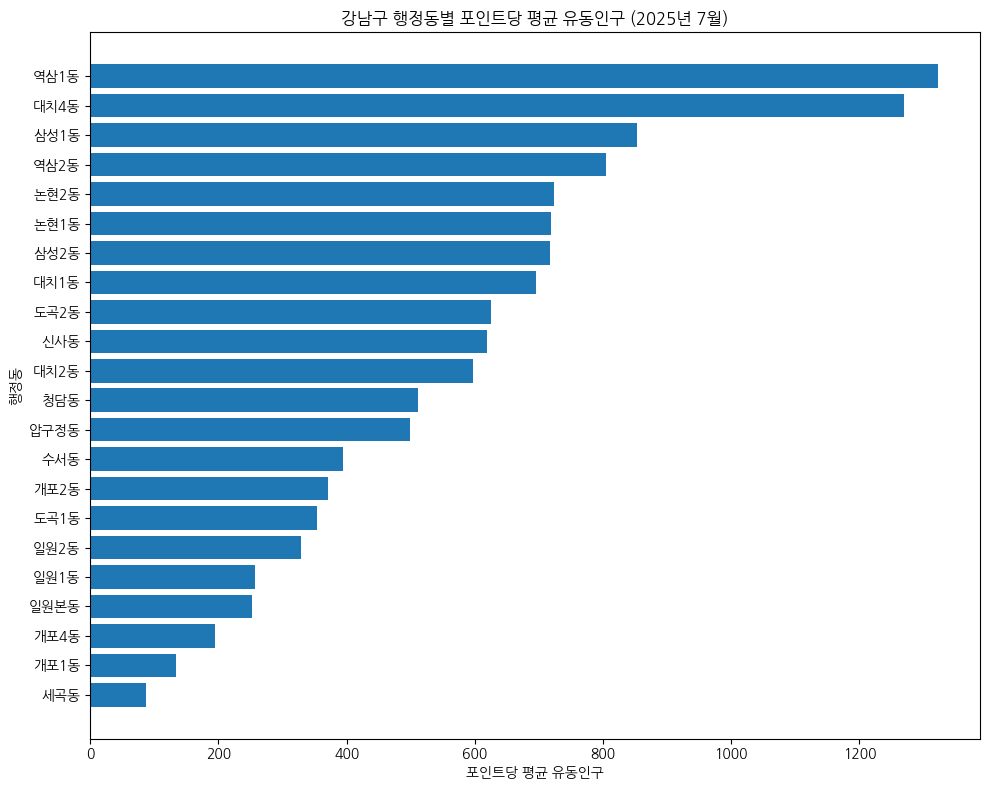

In [30]:
import matplotlib.pyplot as plt

# 한글 폰트 설치 (Colab)
!apt-get -qq install fonts-nanum

import matplotlib.font_manager as fm
fm.fontManager.addfont(
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


# 포인트당 평균 유동인구 정렬
plot_df = dong_age.sort_values(
    "flow_per_point",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["dong_name"],
    plot_df["flow_per_point"]
)

plt.xlabel("포인트당 평균 유동인구")
plt.ylabel("행정동")
plt.title("강남구 행정동별 포인트당 평균 유동인구 (2025년 7월)")

plt.tight_layout()
plt.show()

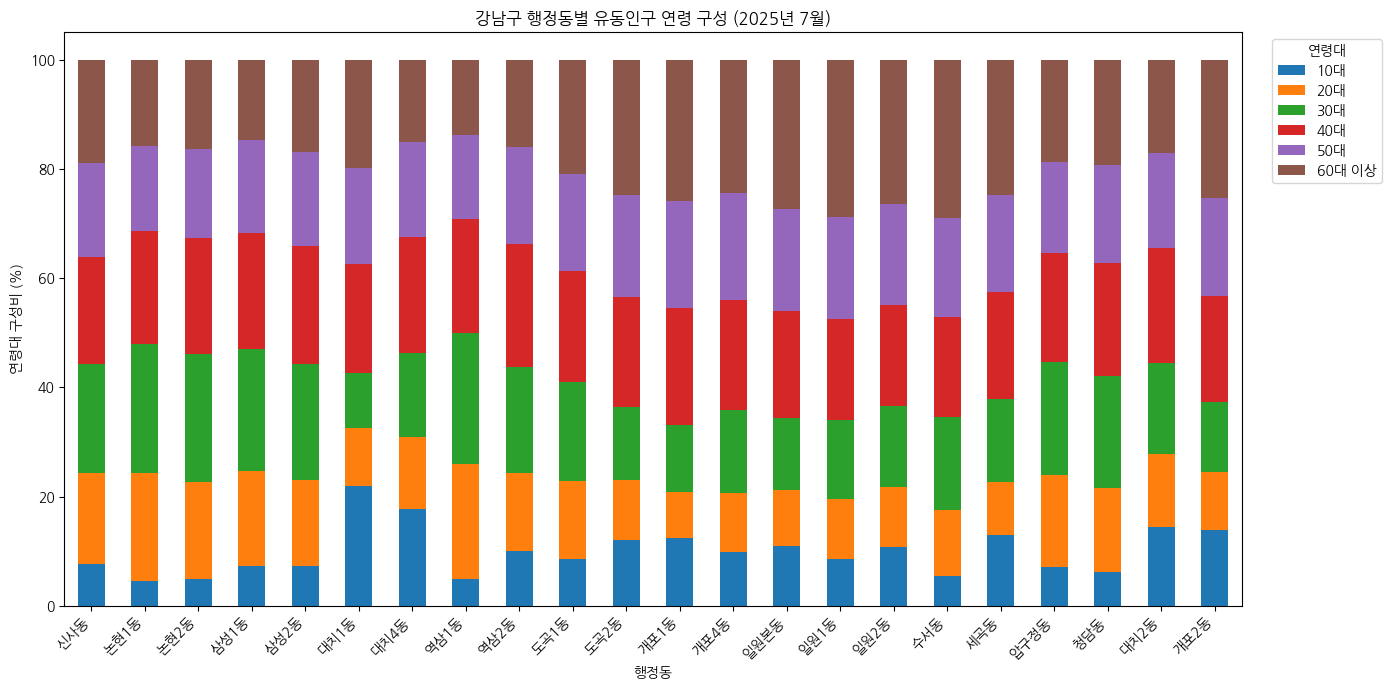

In [31]:
age_ratio_cols = [
    "age_10_ratio",
    "age_20_ratio",
    "age_30_ratio",
    "age_40_ratio",
    "age_50_ratio",
    "age_60_plus_ratio"
]

age_labels = [
    "10대",
    "20대",
    "30대",
    "40대",
    "50대",
    "60대 이상"
]

# 행정동 × 연령 비율
plot_age = (
    dong_age
    .set_index("dong_name")[age_ratio_cols]
    .copy()
)

plot_age.columns = age_labels

# 비율 → %
plot_age = plot_age * 100

# 100% 누적 막대그래프
ax = plot_age.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

ax.set_xlabel("행정동")
ax.set_ylabel("연령대 구성비 (%)")
ax.set_title("강남구 행정동별 유동인구 연령 구성 (2025년 7월)")

plt.legend(
    title="연령대",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [32]:
# ==========================================
# 성·연령 행정동 feature table 저장
# ==========================================

age_feature_cols = [
    "adm_cd",
    "adm_nm",
    "dong_name",

    # 규모
    "total_flow",
    "point_count",
    "flow_per_point",

    # 성별
    "male_ratio",
    "female_ratio",

    # 연령
    "age_10_ratio",
    "age_20_ratio",
    "age_30_ratio",
    "age_40_ratio",
    "age_50_ratio",
    "age_60_plus_ratio"
]

dong_age_features = (
    dong_age[age_feature_cols]
    .copy()
)

output_file = "gangnam_age_features_202507.csv"

dong_age_features.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", output_file)
print("행:", len(dong_age_features))
print("열:", len(dong_age_features.columns))

print("\n===== 저장 데이터 샘플 =====")
print(dong_age_features.head())

저장 완료: gangnam_age_features_202507.csv
행: 22
열: 14

===== 저장 데이터 샘플 =====
    adm_cd          adm_nm dong_name  total_flow  point_count  flow_per_point  \
0  1123051   서울특별시 강남구 신사동       신사동   432575.57          699      618.849170   
1  1123052  서울특별시 강남구 논현1동      논현1동   355919.32          495      719.028929   
2  1123053  서울특별시 강남구 논현2동      논현2동   417862.51          578      722.945519   
3  1123058  서울특별시 강남구 삼성1동      삼성1동   626441.05          734      853.461921   
4  1123059  서울특별시 강남구 삼성2동      삼성2동   360403.43          503      716.507813   

   male_ratio  female_ratio  age_10_ratio  age_20_ratio  age_30_ratio  \
0    0.503326      0.496674      0.075857      0.167979      0.198433   
1    0.523535      0.476465      0.045584      0.196861      0.237137   
2    0.520202      0.479798      0.049218      0.177493      0.233524   
3    0.525791      0.474209      0.072436      0.175119      0.222469   
4    0.523394      0.476606      0.073137      0.156488      0.212963   



In [33]:
from google.colab import files

files.download("gangnam_age_features_202507.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import pandas as pd
import os

# 전처리 완료된 7월 시간대 데이터
time_file = os.path.join(
    "gangnam_flow_population",
    "flow_time_pop_202507_wgs84_gangnam.csv"
)

time_df = pd.read_csv(time_file)

# 불필요한 인덱스 컬럼 제거
time_df = time_df.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

print("===== 기본 정보 =====")
print(f"행 수: {len(time_df):,}")
print(f"열 수: {len(time_df.columns):,}")
print(f"행정동 수: {time_df['adm_cd'].nunique()}")

print("\n===== 컬럼 목록 =====")
print(time_df.columns.tolist())

print("\n===== 데이터 샘플 =====")
print(time_df.head())

print("\n===== 결측치 =====")
print(time_df.isna().sum())

print("\n===== 중복 좌표 =====")
print(
    time_df.duplicated(
        subset=["longitude", "latitude"]
    ).sum()
)

===== 기본 정보 =====
행 수: 14,746
열 수: 32
행정동 수: 22

===== 컬럼 목록 =====
['STD_YM', 'BLOCK_CD', 'X_COORD', 'Y_COORD', 'TMST_00', 'TMST_01', 'TMST_02', 'TMST_03', 'TMST_04', 'TMST_05', 'TMST_06', 'TMST_07', 'TMST_08', 'TMST_09', 'TMST_10', 'TMST_11', 'TMST_12', 'TMST_13', 'TMST_14', 'TMST_15', 'TMST_16', 'TMST_17', 'TMST_18', 'TMST_19', 'TMST_20', 'TMST_21', 'TMST_22', 'TMST_23', 'longitude', 'latitude', 'adm_cd', 'adm_nm']

===== 데이터 샘플 =====
   STD_YM              BLOCK_CD        X_COORD       Y_COORD  TMST_00  \
0  202507  11230510101020000001  956883.991787  1.947729e+06     0.69   
1  202507  11230510101020000001  956933.991787  1.947679e+06     0.56   
2  202507  11230510101020000001  956933.991787  1.947729e+06     0.33   
3  202507  11230510101020000001  956983.991787  1.947629e+06     0.48   
4  202507  11230510101020000001  956983.991787  1.947679e+06     0.18   

   TMST_01  TMST_02  TMST_03  TMST_04  TMST_05  ...  TMST_18  TMST_19  \
0     0.38     0.28     0.23     0.28     0.61 

In [35]:
# 시간대 컬럼 선택
time_cols = [
    f"TMST_{hour:02d}"
    for hour in range(24)
]

print("===== 시간대 컬럼 =====")
print(time_cols)

print(f"\n시간대 변수 수: {len(time_cols)}")

print("\n===== 기초통계 =====")
print(
    time_df[time_cols]
    .describe()
    .T
)

===== 시간대 컬럼 =====
['TMST_00', 'TMST_01', 'TMST_02', 'TMST_03', 'TMST_04', 'TMST_05', 'TMST_06', 'TMST_07', 'TMST_08', 'TMST_09', 'TMST_10', 'TMST_11', 'TMST_12', 'TMST_13', 'TMST_14', 'TMST_15', 'TMST_16', 'TMST_17', 'TMST_18', 'TMST_19', 'TMST_20', 'TMST_21', 'TMST_22', 'TMST_23']

시간대 변수 수: 24

===== 기초통계 =====
           count       mean        std  min   25%   50%      75%      max
TMST_00  14746.0   5.916403  10.160945  0.0  0.38  1.88   6.7800   143.51
TMST_01  14746.0   3.933551   6.846837  0.0  0.25  1.24   4.4700    95.55
TMST_02  14746.0   2.800406   4.896341  0.0  0.18  0.89   3.1800    73.56
TMST_03  14746.0   2.295148   4.015996  0.0  0.15  0.74   2.6200    71.50
TMST_04  14746.0   2.295635   3.969730  0.0  0.18  0.76   2.6700    84.25
TMST_05  14746.0   3.648172   6.368205  0.0  0.28  1.24   4.3200   140.28
TMST_06  14746.0   8.101134  14.380702  0.0  0.56  2.54   9.3000   261.72
TMST_07  14746.0  16.234248  29.996984  0.0  0.94  4.71  17.9300   466.34
TMST_08  14746.0  

===== 강남구 전체 시간대 분석 =====
최대 유동 시간: 17시 (552,356.61)
최소 유동 시간: 03시 (33,844.25)


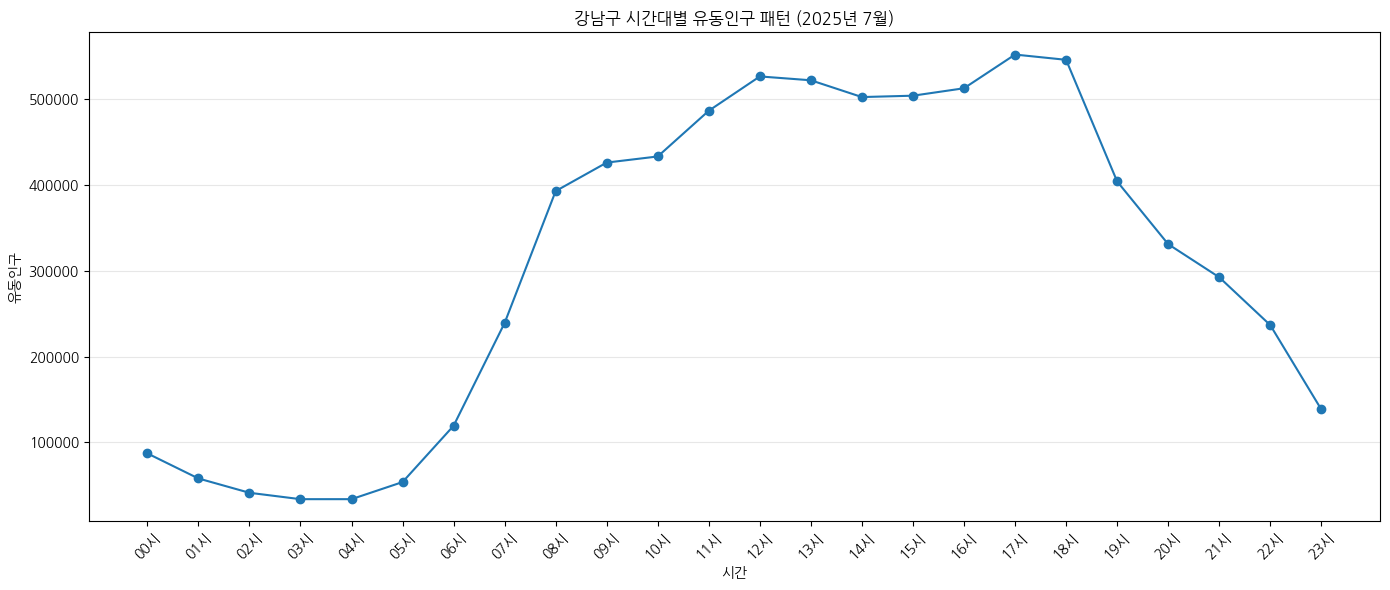

In [36]:
import matplotlib.pyplot as plt

# ==========================================
# 1. 시간대별 강남구 전체 유동인구
# ==========================================

hourly_total = time_df[time_cols].sum()

# 보기 편한 시간 라벨
hour_labels = [
    f"{hour:02d}시"
    for hour in range(24)
]


# ==========================================
# 2. 최대/최소 시간 확인
# ==========================================

peak_col = hourly_total.idxmax()
low_col = hourly_total.idxmin()

peak_hour = int(peak_col.split("_")[1])
low_hour = int(low_col.split("_")[1])

print("===== 강남구 전체 시간대 분석 =====")

print(
    f"최대 유동 시간: {peak_hour:02d}시 "
    f"({hourly_total[peak_col]:,.2f})"
)

print(
    f"최소 유동 시간: {low_hour:02d}시 "
    f"({hourly_total[low_col]:,.2f})"
)


# ==========================================
# 3. 24시간 그래프
# ==========================================

plt.figure(figsize=(14, 6))

plt.plot(
    hour_labels,
    hourly_total.values,
    marker="o"
)

plt.xlabel("시간")
plt.ylabel("유동인구")
plt.title(
    "강남구 시간대별 유동인구 패턴 (2025년 7월)"
)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [37]:
# ==========================================
# 행정동 × 24시간 유동인구 집계
# ==========================================

dong_time = (
    time_df
    .groupby(["adm_cd", "adm_nm"])[time_cols]
    .sum()
    .reset_index()
)

# 행정동명 간소화
dong_time["dong_name"] = (
    dong_time["adm_nm"]
    .str.replace(
        "서울특별시 강남구 ",
        "",
        regex=False
    )
)

print("행정동 수:", len(dong_time))

print("\n===== 샘플 =====")
print(
    dong_time[
        ["dong_name"] + time_cols
    ].head()
)

행정동 수: 22

===== 샘플 =====
  dong_name  TMST_00  TMST_01  TMST_02  TMST_03  TMST_04  TMST_05  TMST_06  \
0       신사동  5402.11  3580.94  2547.86  2110.18  2273.87  3630.37  7100.63   
1      논현1동  4976.78  3540.71  2590.73  2148.90  2004.28  2624.01  5261.08   
2      논현2동  4955.01  3434.49  2447.03  2003.49  1853.42  2639.66  5621.39   
3      삼성1동  4377.31  2753.97  1910.74  1556.01  1685.97  3368.39  8807.78   
4      삼성2동  4164.84  2845.31  1978.02  1601.04  1471.62  2111.98  5190.96   

    TMST_07   TMST_08  ...   TMST_14   TMST_15   TMST_16   TMST_17   TMST_18  \
0  12452.20  19674.40  ...  29473.38  29833.33  30688.31  32875.09  33337.83   
1  10000.07  17416.46  ...  23388.09  23512.99  24206.92  26401.69  27870.54   
2  11422.34  22232.40  ...  28625.78  28556.17  28920.97  31031.10  32171.76   
3  16860.98  29519.70  ...  49029.56  48582.22  48044.64  48768.77  45667.22   
4  11006.64  20118.05  ...  23951.87  23997.02  24656.98  26931.34  27346.85   

    TMST_19   TMST_20   

In [38]:
# ==========================================
# 24시간 전체 합계
# ==========================================

dong_time["time_total"] = (
    dong_time[time_cols]
    .sum(axis=1)
)


# ==========================================
# 시간대 구간 정의
# ==========================================

night_cols = [
    f"TMST_{h:02d}"
    for h in range(0, 6)
]

morning_cols = [
    f"TMST_{h:02d}"
    for h in range(6, 11)
]

daytime_cols = [
    f"TMST_{h:02d}"
    for h in range(11, 19)
]

evening_cols = [
    f"TMST_{h:02d}"
    for h in range(19, 24)
]


# ==========================================
# 시간대별 합계
# ==========================================

dong_time["night_flow"] = (
    dong_time[night_cols].sum(axis=1)
)

dong_time["morning_flow"] = (
    dong_time[morning_cols].sum(axis=1)
)

dong_time["daytime_flow"] = (
    dong_time[daytime_cols].sum(axis=1)
)

dong_time["evening_flow"] = (
    dong_time[evening_cols].sum(axis=1)
)


# ==========================================
# 시간대별 구성비
# ==========================================

for period in [
    "night",
    "morning",
    "daytime",
    "evening"
]:
    dong_time[f"{period}_ratio"] = (
        dong_time[f"{period}_flow"]
        / dong_time["time_total"]
    )


# ==========================================
# 각 행정동 피크 시간
# ==========================================

dong_time["peak_hour"] = (
    dong_time[time_cols]
    .idxmax(axis=1)
    .str.replace("TMST_", "")
    .astype(int)
)


# ==========================================
# 비율 검증
# ==========================================

dong_time["period_ratio_sum"] = (
    dong_time[
        [
            "night_ratio",
            "morning_ratio",
            "daytime_ratio",
            "evening_ratio"
        ]
    ]
    .sum(axis=1)
)

print(
    dong_time[
        [
            "dong_name",
            "night_ratio",
            "morning_ratio",
            "daytime_ratio",
            "evening_ratio",
            "peak_hour",
            "period_ratio_sum"
        ]
    ].to_string(index=False)
)

dong_name  night_ratio  morning_ratio  daytime_ratio  evening_ratio  peak_hour  period_ratio_sum
      신사동     0.045183       0.197944       0.557845       0.199028         18               1.0
     논현1동     0.050251       0.204226       0.552071       0.193453         18               1.0
     논현2동     0.041480       0.213117       0.570003       0.175400         18               1.0
     삼성1동     0.024986       0.199860       0.620592       0.154562         12               1.0
     삼성2동     0.039324       0.218743       0.563141       0.178792         18               1.0
     대치1동     0.039833       0.207037       0.529259       0.223871         17               1.0
     대치4동     0.037622       0.193436       0.564562       0.204380         17               1.0
     역삼1동     0.039293       0.206109       0.572222       0.182376         18               1.0
     역삼2동     0.043150       0.215866       0.559086       0.181898         12               1.0
     도곡1동     0.036247       0

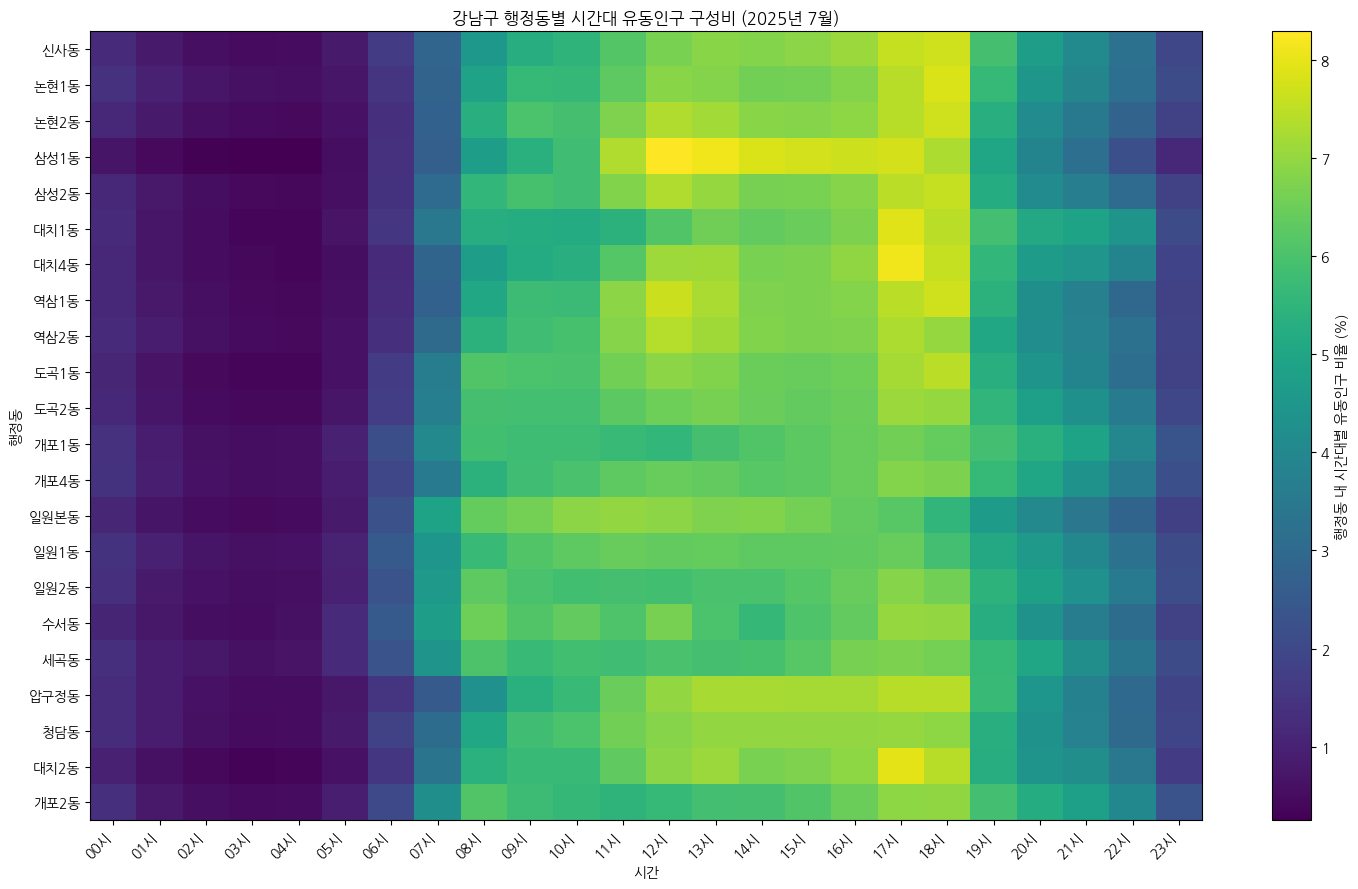

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 행정동별 24시간 구성비 계산
# ==========================================

time_ratio = (
    dong_time[time_cols]
    .div(dong_time["time_total"], axis=0)
    * 100
)

time_ratio.index = dong_time["dong_name"]

# 보기 편한 시간 라벨
hour_labels = [
    f"{h:02d}시"
    for h in range(24)
]


# ==========================================
# Heatmap
# ==========================================

fig, ax = plt.subplots(figsize=(15, 9))

im = ax.imshow(
    time_ratio.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(hour_labels))
)
ax.set_xticklabels(
    hour_labels,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    np.arange(len(time_ratio.index))
)
ax.set_yticklabels(
    time_ratio.index
)

ax.set_xlabel("시간")
ax.set_ylabel("행정동")

ax.set_title(
    "강남구 행정동별 시간대 유동인구 구성비 (2025년 7월)"
)

cbar = plt.colorbar(
    im,
    ax=ax
)

cbar.set_label(
    "행정동 내 시간대별 유동인구 비율 (%)"
)

plt.tight_layout()
plt.show()

In [40]:
# ==========================================
# 1. 행정동별 포인트 수
# ==========================================

time_point_count = (
    time_df
    .groupby(["adm_cd", "adm_nm"])
    .size()
    .reset_index(name="time_point_count")
)

dong_time = dong_time.merge(
    time_point_count,
    on=["adm_cd", "adm_nm"],
    how="left"
)


# ==========================================
# 2. 포인트당 평균 유동인구
# ==========================================

dong_time["time_flow_per_point"] = (
    dong_time["time_total"]
    / dong_time["time_point_count"]
)


# ==========================================
# 3. 피크 시간 유동인구 및 비율
# ==========================================

dong_time["peak_hour_flow"] = (
    dong_time[time_cols]
    .max(axis=1)
)

dong_time["peak_hour_ratio"] = (
    dong_time["peak_hour_flow"]
    / dong_time["time_total"]
)


# ==========================================
# 4. 최종 feature 선택
# ==========================================

time_feature_cols = [
    "adm_cd",
    "adm_nm",
    "dong_name",

    # 규모
    "time_total",
    "time_point_count",
    "time_flow_per_point",

    # 시간대 구성
    "night_ratio",
    "morning_ratio",
    "daytime_ratio",
    "evening_ratio",

    # 피크 특성
    "peak_hour",
    "peak_hour_ratio"
]

dong_time_features = (
    dong_time[time_feature_cols]
    .copy()
)


# ==========================================
# 5. 결과 확인
# ==========================================

print("===== 시간대 최종 Feature =====")
print(
    dong_time_features
    .sort_values(
        "peak_hour_ratio",
        ascending=False
    )
    .to_string(index=False)
)

===== 시간대 최종 Feature =====
 adm_cd         adm_nm dong_name  time_total  time_point_count  time_flow_per_point  night_ratio  morning_ratio  daytime_ratio  evening_ratio  peak_hour  peak_hour_ratio
1123058 서울특별시 강남구 삼성1동      삼성1동   626451.36               736           851.156739     0.024986       0.199860       0.620592       0.154562         12         0.082909
1123063 서울특별시 강남구 대치4동      대치4동   355366.00               280          1269.164286     0.037622       0.193436       0.564562       0.204380         17         0.081130
1123079 서울특별시 강남구 대치2동      대치2동   482635.22               809           596.582472     0.033258       0.215947       0.560630       0.190164         17         0.079686
1123060 서울특별시 강남구 대치1동      대치1동   224126.50               322           696.045031     0.039833       0.207037       0.529259       0.223871         17         0.078932
1123052 서울특별시 강남구 논현1동      논현1동   355924.12               495           719.038626     0.050251       0.204226       0.552

In [41]:
from google.colab import files

output_file = "gangnam_time_features_202507.csv"

dong_time_features.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", output_file)
print("행:", len(dong_time_features))
print("열:", len(dong_time_features.columns))

files.download(output_file)

저장 완료: gangnam_time_features_202507.csv
행: 22
열: 12


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
import pandas as pd
import os

# 전처리 완료된 7월 요일 데이터
weekday_file = os.path.join(
    "gangnam_flow_population",
    "flow_wkdy_pop_202507_wgs84_gangnam.csv"
)

weekday_df = pd.read_csv(weekday_file)

# 불필요한 인덱스 컬럼 제거
weekday_df = weekday_df.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

print("===== 기본 정보 =====")
print(f"행 수: {len(weekday_df):,}")
print(f"열 수: {len(weekday_df.columns):,}")
print(f"행정동 수: {weekday_df['adm_cd'].nunique()}")

print("\n===== 컬럼 목록 =====")
print(weekday_df.columns.tolist())

print("\n===== 데이터 샘플 =====")
print(weekday_df.head())

print("\n===== 결측치 =====")
print(weekday_df.isna().sum())

print("\n===== 중복 좌표 =====")
print(
    weekday_df.duplicated(
        subset=["longitude", "latitude"]
    ).sum()
)

===== 기본 정보 =====
행 수: 14,837
열 수: 15
행정동 수: 22

===== 컬럼 목록 =====
['STD_YM', 'BLOCK_CD', 'X_COORD', 'Y_COORD', 'FLOW_POP_CNT_MON', 'FLOW_POP_CNT_TUS', 'FLOW_POP_CNT_WED', 'FLOW_POP_CNT_THU', 'FLOW_POP_CNT_FRI', 'FLOW_POP_CNT_SAT', 'FLOW_POP_CNT_SUN', 'longitude', 'latitude', 'adm_cd', 'adm_nm']

===== 데이터 샘플 =====
   STD_YM              BLOCK_CD        X_COORD       Y_COORD  \
0  202507  11230510101020000001  956883.991787  1.947729e+06   
1  202507  11230510101020000001  956933.991787  1.947679e+06   
2  202507  11230510101020000001  956933.991787  1.947729e+06   
3  202507  11230510101020000001  956983.991787  1.947629e+06   
4  202507  11230510101020000001  956983.991787  1.947679e+06   

   FLOW_POP_CNT_MON  FLOW_POP_CNT_TUS  FLOW_POP_CNT_WED  FLOW_POP_CNT_THU  \
0             44.86             46.81             47.22             47.57   
1             37.24             38.89             39.37             39.65   
2             19.96             21.03             21.29            

In [43]:
weekday_cols = [
    "FLOW_POP_CNT_MON",
    "FLOW_POP_CNT_TUS",
    "FLOW_POP_CNT_WED",
    "FLOW_POP_CNT_THU",
    "FLOW_POP_CNT_FRI",
    "FLOW_POP_CNT_SAT",
    "FLOW_POP_CNT_SUN"
]

print("===== 요일별 컬럼 =====")
print(weekday_cols)

print(f"\n요일 변수 수: {len(weekday_cols)}")

print("\n===== 기초통계 =====")
print(
    weekday_df[weekday_cols]
    .describe()
    .T
)

===== 요일별 컬럼 =====
['FLOW_POP_CNT_MON', 'FLOW_POP_CNT_TUS', 'FLOW_POP_CNT_WED', 'FLOW_POP_CNT_THU', 'FLOW_POP_CNT_FRI', 'FLOW_POP_CNT_SAT', 'FLOW_POP_CNT_SUN']

요일 변수 수: 7

===== 기초통계 =====
                    count        mean          std  min    25%     50%  \
FLOW_POP_CNT_MON  14837.0  526.209986   996.111234  0.0  17.63  121.21   
FLOW_POP_CNT_TUS  14837.0  544.599420  1031.051269  0.0  18.01  124.23   
FLOW_POP_CNT_WED  14837.0  545.424329  1033.444836  0.0  18.08  124.33   
FLOW_POP_CNT_THU  14837.0  547.342979  1039.491793  0.0  17.98  123.70   
FLOW_POP_CNT_FRI  14837.0  556.907822  1053.223939  0.0  18.69  126.62   
FLOW_POP_CNT_SAT  14837.0  429.037437   781.942136  0.0  22.86  141.17   
FLOW_POP_CNT_SUN  14837.0  347.444832   618.470484  0.0  20.32  121.77   

                     75%       max  
FLOW_POP_CNT_MON  567.64  13850.72  
FLOW_POP_CNT_TUS  587.55  14231.39  
FLOW_POP_CNT_WED  587.55  14240.03  
FLOW_POP_CNT_THU  587.22  14119.50  
FLOW_POP_CNT_FRI  597.10  14564.

===== 강남구 전체 요일별 유동인구 =====
월요일 : 7,807,377.56
화요일 : 8,080,221.60
수요일 : 8,092,460.77
목요일 : 8,120,927.78
금요일 : 8,262,841.35
토요일 : 6,365,628.45
일요일 : 5,155,038.97

최대 유동 요일: 금요일 (8,262,841.35)
최소 유동 요일: 일요일 (5,155,038.97)


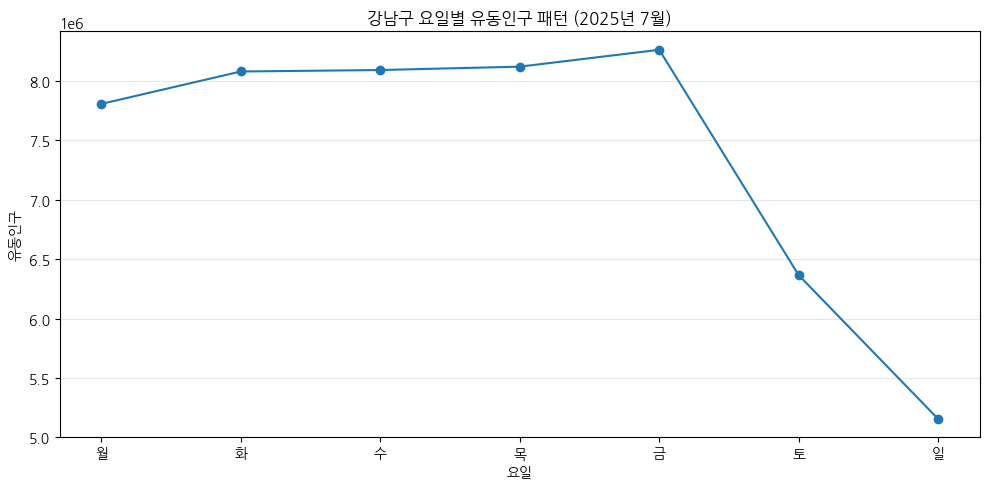

In [44]:
import matplotlib.pyplot as plt

# ==========================================
# 1. 강남구 전체 요일별 유동인구
# ==========================================

weekday_total = weekday_df[weekday_cols].sum()

day_labels = [
    "월", "화", "수", "목", "금", "토", "일"
]

# 최대 / 최소 요일
max_idx = weekday_total.values.argmax()
min_idx = weekday_total.values.argmin()

print("===== 강남구 전체 요일별 유동인구 =====")

for day, value in zip(day_labels, weekday_total.values):
    print(f"{day}요일 : {value:,.2f}")

print(
    f"\n최대 유동 요일: {day_labels[max_idx]}요일 "
    f"({weekday_total.iloc[max_idx]:,.2f})"
)

print(
    f"최소 유동 요일: {day_labels[min_idx]}요일 "
    f"({weekday_total.iloc[min_idx]:,.2f})"
)


# ==========================================
# 2. 그래프
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    day_labels,
    weekday_total.values,
    marker="o"
)

plt.xlabel("요일")
plt.ylabel("유동인구")
plt.title("강남구 요일별 유동인구 패턴 (2025년 7월)")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [45]:
# ==========================================
# 행정동 × 요일 유동인구 집계
# ==========================================

dong_weekday = (
    weekday_df
    .groupby(["adm_cd", "adm_nm"])[weekday_cols]
    .sum()
    .reset_index()
)

dong_weekday["dong_name"] = (
    dong_weekday["adm_nm"]
    .str.replace(
        "서울특별시 강남구 ",
        "",
        regex=False
    )
)

print("행정동 수:", len(dong_weekday))

print("\n===== 샘플 =====")
print(
    dong_weekday[
        ["dong_name"] + weekday_cols
    ].head()
)

행정동 수: 22

===== 샘플 =====
  dong_name  FLOW_POP_CNT_MON  FLOW_POP_CNT_TUS  FLOW_POP_CNT_WED  \
0       신사동         435410.86         454142.58         452731.34   
1      논현1동         383088.71         394488.07         392703.88   
2      논현2동         453023.98         473294.25         474049.20   
3      삼성1동         601634.85         637185.41         663932.53   
4      삼성2동         392745.56         407375.67         407627.44   

   FLOW_POP_CNT_THU  FLOW_POP_CNT_FRI  FLOW_POP_CNT_SAT  FLOW_POP_CNT_SUN  
0         452403.75         475759.16         415222.35         327006.72  
1         392260.07         403836.34         285696.28         211460.36  
2         472215.75         474443.37         307681.51         228875.80  
3         701363.53         702657.37         579358.78         468229.53  
4         409871.57         406908.21         259235.76         203176.82  


In [46]:
# ==========================================
# 1. 요일 그룹 정의
# ==========================================

workday_cols = [
    "FLOW_POP_CNT_MON",
    "FLOW_POP_CNT_TUS",
    "FLOW_POP_CNT_WED",
    "FLOW_POP_CNT_THU",
    "FLOW_POP_CNT_FRI"
]

weekend_cols = [
    "FLOW_POP_CNT_SAT",
    "FLOW_POP_CNT_SUN"
]


# ==========================================
# 2. 전체 / 평일 / 주말 유동인구
# ==========================================

dong_weekday["week_total"] = (
    dong_weekday[weekday_cols]
    .sum(axis=1)
)

dong_weekday["workday_total"] = (
    dong_weekday[workday_cols]
    .sum(axis=1)
)

dong_weekday["weekend_total"] = (
    dong_weekday[weekend_cols]
    .sum(axis=1)
)


# ==========================================
# 3. 평일 / 주말 비율
# ==========================================

dong_weekday["workday_ratio"] = (
    dong_weekday["workday_total"]
    / dong_weekday["week_total"]
)

dong_weekday["weekend_ratio"] = (
    dong_weekday["weekend_total"]
    / dong_weekday["week_total"]
)


# ==========================================
# 4. 평일 / 주말 하루 평균
# ==========================================

dong_weekday["workday_daily_avg"] = (
    dong_weekday["workday_total"] / 5
)

dong_weekday["weekend_daily_avg"] = (
    dong_weekday["weekend_total"] / 2
)


# ==========================================
# 5. 주말-평일 활동 지수
# ==========================================

dong_weekday["weekend_weekday_index"] = (
    dong_weekday["weekend_daily_avg"]
    / dong_weekday["workday_daily_avg"]
)


# ==========================================
# 6. 토요일 / 일요일 비율
# ==========================================

dong_weekday["sat_ratio"] = (
    dong_weekday["FLOW_POP_CNT_SAT"]
    / dong_weekday["week_total"]
)

dong_weekday["sun_ratio"] = (
    dong_weekday["FLOW_POP_CNT_SUN"]
    / dong_weekday["week_total"]
)


# ==========================================
# 7. 최고 활동 요일
# ==========================================

day_map = {
    "FLOW_POP_CNT_MON": "월",
    "FLOW_POP_CNT_TUS": "화",
    "FLOW_POP_CNT_WED": "수",
    "FLOW_POP_CNT_THU": "목",
    "FLOW_POP_CNT_FRI": "금",
    "FLOW_POP_CNT_SAT": "토",
    "FLOW_POP_CNT_SUN": "일"
}

dong_weekday["peak_day"] = (
    dong_weekday[weekday_cols]
    .idxmax(axis=1)
    .map(day_map)
)

dong_weekday["peak_day_flow"] = (
    dong_weekday[weekday_cols]
    .max(axis=1)
)

dong_weekday["peak_day_ratio"] = (
    dong_weekday["peak_day_flow"]
    / dong_weekday["week_total"]
)


# ==========================================
# 8. 결과 확인
# ==========================================

print(
    dong_weekday[
        [
            "dong_name",
            "workday_ratio",
            "weekend_ratio",
            "workday_daily_avg",
            "weekend_daily_avg",
            "weekend_weekday_index",
            "sat_ratio",
            "sun_ratio",
            "peak_day",
            "peak_day_ratio"
        ]
    ]
    .sort_values(
        "weekend_weekday_index",
        ascending=False
    )
    .to_string(index=False)
)

print("\n===== 비율 검증 =====")

dong_weekday["weekday_ratio_sum"] = (
    dong_weekday["workday_ratio"]
    + dong_weekday["weekend_ratio"]
)

print(
    dong_weekday[
        ["dong_name", "weekday_ratio_sum"]
    ].to_string(index=False)
)

dong_name  workday_ratio  weekend_ratio  workday_daily_avg  weekend_daily_avg  weekend_weekday_index  sat_ratio  sun_ratio peak_day  peak_day_ratio
     개포2동       0.696192       0.303808         229521.340         250399.605               1.090964   0.158516   0.145292        토        0.158516
     대치1동       0.716218       0.283782         224780.136         222657.700               0.990558   0.153293   0.130489        토        0.153293
     일원1동       0.718775       0.281225          96610.732          94498.840               0.978140   0.148722   0.132503        토        0.148722
     개포4동       0.724727       0.275273         120237.944         114175.075               0.949576   0.143318   0.131956        금        0.149021
      세곡동       0.726441       0.273559         197454.512         185890.455               0.941434   0.142992   0.130567        금        0.149129
     대치4동       0.751973       0.248027         372075.702         306808.605               0.824587   0.136637 

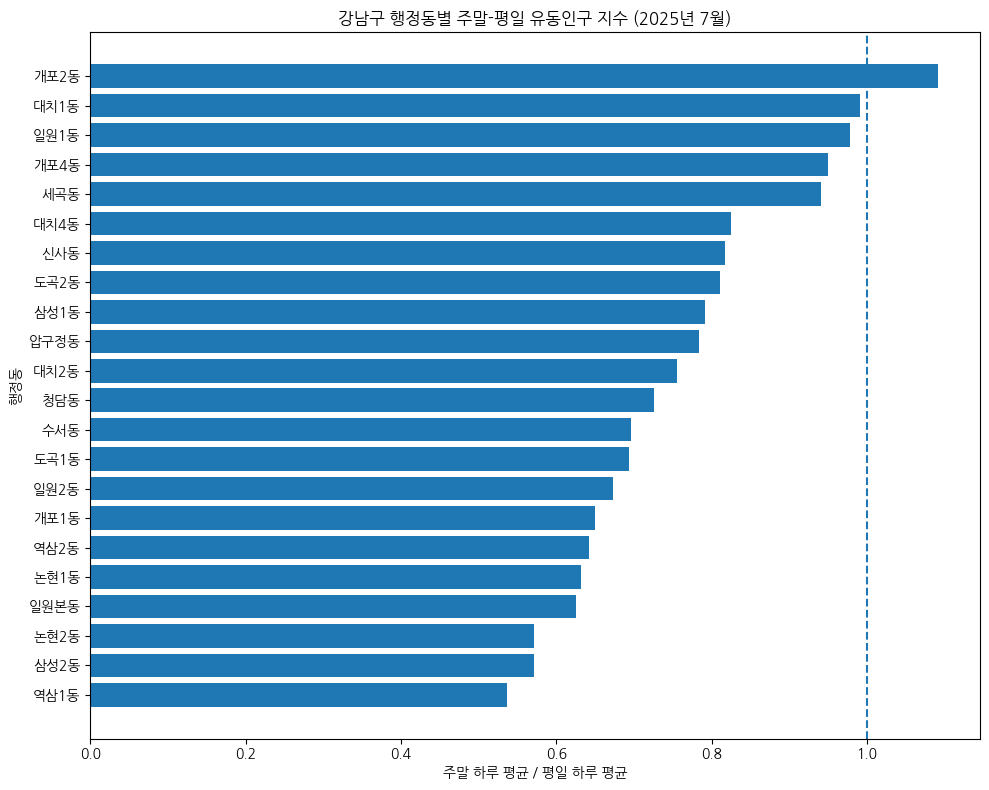

In [47]:
# 주말-평일 활동 지수 정렬
plot_weekend = (
    dong_weekday
    .sort_values(
        "weekend_weekday_index",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_weekend["dong_name"],
    plot_weekend["weekend_weekday_index"]
)

# 평일 = 주말 기준선
plt.axvline(
    x=1,
    linestyle="--"
)

plt.xlabel("주말 하루 평균 / 평일 하루 평균")
plt.ylabel("행정동")

plt.title(
    "강남구 행정동별 주말-평일 유동인구 지수 (2025년 7월)"
)

plt.tight_layout()
plt.show()

In [48]:
# ==========================================
# 포인트 수
# ==========================================

weekday_point_count = (
    weekday_df
    .groupby(["adm_cd", "adm_nm"])
    .size()
    .reset_index(name="weekday_point_count")
)

dong_weekday = dong_weekday.merge(
    weekday_point_count,
    on=["adm_cd", "adm_nm"],
    how="left"
)


# ==========================================
# 포인트당 유동인구
# ==========================================

dong_weekday["week_flow_per_point"] = (
    dong_weekday["week_total"]
    / dong_weekday["weekday_point_count"]
)


# ==========================================
# 최종 feature
# ==========================================

weekday_feature_cols = [
    "adm_cd",
    "adm_nm",
    "dong_name",

    # 규모
    "week_total",
    "weekday_point_count",
    "week_flow_per_point",

    # 평일 / 주말 특성
    "workday_ratio",
    "weekend_ratio",
    "weekend_weekday_index",

    # 주말 내부 특성
    "sat_ratio",
    "sun_ratio",

    # 피크
    "peak_day",
    "peak_day_ratio"
]

dong_weekday_features = (
    dong_weekday[weekday_feature_cols]
    .copy()
)

print(
    dong_weekday_features.head()
)

    adm_cd          adm_nm dong_name  week_total  weekday_point_count  \
0  1123051   서울특별시 강남구 신사동       신사동  3012676.76                  700   
1  1123052  서울특별시 강남구 논현1동      논현1동  2463533.71                  495   
2  1123053  서울특별시 강남구 논현2동      논현2동  2883583.86                  578   
3  1123058  서울특별시 강남구 삼성1동      삼성1동  4354362.00                  761   
4  1123059  서울특별시 강남구 삼성2동      삼성2동  2486941.03                  503   

   week_flow_per_point  workday_ratio  weekend_ratio  weekend_weekday_index  \
0          4303.823943       0.753631       0.246369               0.817272   
1          4976.835778       0.798194       0.201806               0.632072   
2          4988.899412       0.813927       0.186073               0.571529   
3          5721.894875       0.759416       0.240584               0.792002   
4          4944.216759       0.814064       0.185936               0.571013   

   sat_ratio  sun_ratio peak_day  peak_day_ratio  
0   0.137825   0.108544        금   

In [49]:
from google.colab import files

output_file = "gangnam_weekday_features_202507.csv"

dong_weekday_features.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", output_file)
print("행:", len(dong_weekday_features))
print("열:", len(dong_weekday_features.columns))

files.download(output_file)

저장 완료: gangnam_weekday_features_202507.csv
행: 22
열: 13


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
# ==========================================
# 1. 성·연령 + 시간대 결합
# ==========================================

gangnam_features = dong_age_features.merge(
    dong_time_features.drop(
        columns=["adm_nm", "dong_name"]
    ),
    on="adm_cd",
    how="inner"
)

# ==========================================
# 2. 요일 데이터 결합
# ==========================================

gangnam_features = gangnam_features.merge(
    dong_weekday_features.drop(
        columns=["adm_nm", "dong_name"]
    ),
    on="adm_cd",
    how="inner"
)

# ==========================================
# 3. 결과 확인
# ==========================================

print("===== 7월 DB1 통합 Feature Table =====")
print("행:", len(gangnam_features))
print("열:", len(gangnam_features.columns))

print("\n행정동 수:")
print(gangnam_features["adm_cd"].nunique())

print("\n컬럼:")
print(gangnam_features.columns.tolist())

print("\n샘플:")
print(gangnam_features.head())

===== 7월 DB1 통합 Feature Table =====
행: 22
열: 33

행정동 수:
22

컬럼:
['adm_cd', 'adm_nm', 'dong_name', 'total_flow', 'point_count', 'flow_per_point', 'male_ratio', 'female_ratio', 'age_10_ratio', 'age_20_ratio', 'age_30_ratio', 'age_40_ratio', 'age_50_ratio', 'age_60_plus_ratio', 'time_total', 'time_point_count', 'time_flow_per_point', 'night_ratio', 'morning_ratio', 'daytime_ratio', 'evening_ratio', 'peak_hour', 'peak_hour_ratio', 'week_total', 'weekday_point_count', 'week_flow_per_point', 'workday_ratio', 'weekend_ratio', 'weekend_weekday_index', 'sat_ratio', 'sun_ratio', 'peak_day', 'peak_day_ratio']

샘플:
    adm_cd          adm_nm dong_name  total_flow  point_count  flow_per_point  \
0  1123051   서울특별시 강남구 신사동       신사동   432575.57          699      618.849170   
1  1123052  서울특별시 강남구 논현1동      논현1동   355919.32          495      719.028929   
2  1123053  서울특별시 강남구 논현2동      논현2동   417862.51          578      722.945519   
3  1123058  서울특별시 강남구 삼성1동      삼성1동   626441.05          734    

In [51]:
check_cols = [
    "dong_name",
    "point_count",
    "time_point_count",
    "weekday_point_count"
]

print(
    gangnam_features[check_cols]
    .to_string(index=False)
)

dong_name  point_count  time_point_count  weekday_point_count
      신사동          699               699                  700
     논현1동          495               495                  495
     논현2동          578               578                  578
     삼성1동          734               736                  761
     삼성2동          503               503                  503
     대치1동          322               322                  322
     대치4동          280               280                  280
     역삼1동          947               947                  947
     역삼2동          447               447                  447
     도곡1동          405               405                  405
     도곡2동          410               410                  410
     개포1동          620               621                  626
     개포4동          609               610                  612
     일원본동          812               812                  824
     일원1동          374               374                  374
     일원2

In [52]:
from google.colab import files

output_file = "gangnam_db1_features_202507.csv"

gangnam_features.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", output_file)
print(
    f"데이터 구조: "
    f"{len(gangnam_features)}행 × "
    f"{len(gangnam_features.columns)}열"
)

files.download(output_file)

저장 완료: gangnam_db1_features_202507.csv
데이터 구조: 22행 × 33열


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
candidate_features = [
    # 공간 활동 규모/집중
    "flow_per_point",

    # 성별
    "male_ratio",

    # 연령 구성
    "age_10_ratio",
    "age_20_ratio",
    "age_30_ratio",
    "age_40_ratio",
    "age_50_ratio",
    # age_60_plus_ratio 제외 → 나머지로 결정 가능

    # 시간대 구성
    "night_ratio",
    "morning_ratio",
    "daytime_ratio",
    # evening_ratio 제외 → 나머지로 결정 가능

    # 시간 집중도
    "peak_hour_ratio",

    # 요일 패턴
    "weekend_weekday_index",

    # 요일 집중도
    "peak_day_ratio"
]

X_candidate = gangnam_features[candidate_features]

print("ML 후보 feature 수:", len(candidate_features))

print("\n===== 후보 Feature =====")
print(candidate_features)

print("\n===== 기초통계 =====")
print(X_candidate.describe().T)

ML 후보 feature 수: 13

===== 후보 Feature =====
['flow_per_point', 'male_ratio', 'age_10_ratio', 'age_20_ratio', 'age_30_ratio', 'age_40_ratio', 'age_50_ratio', 'night_ratio', 'morning_ratio', 'daytime_ratio', 'peak_hour_ratio', 'weekend_weekday_index', 'peak_day_ratio']

===== 기초통계 =====
                       count        mean         std        min         25%  \
flow_per_point          22.0  560.263514  325.598891  86.299263  334.689232   
male_ratio              22.0    0.508463    0.018652   0.470581    0.499643   
age_10_ratio            22.0    0.099816    0.044077   0.045584    0.071561   
age_20_ratio            22.0    0.136816    0.034881   0.083787    0.107651   
age_30_ratio            22.0    0.174396    0.041013   0.099927    0.145982   
age_40_ratio            22.0    0.203050    0.011210   0.183300    0.196115   
age_50_ratio            22.0    0.176563    0.010788   0.154068    0.171751   
night_ratio             22.0    0.043455    0.007081   0.024986    0.039451   
mor

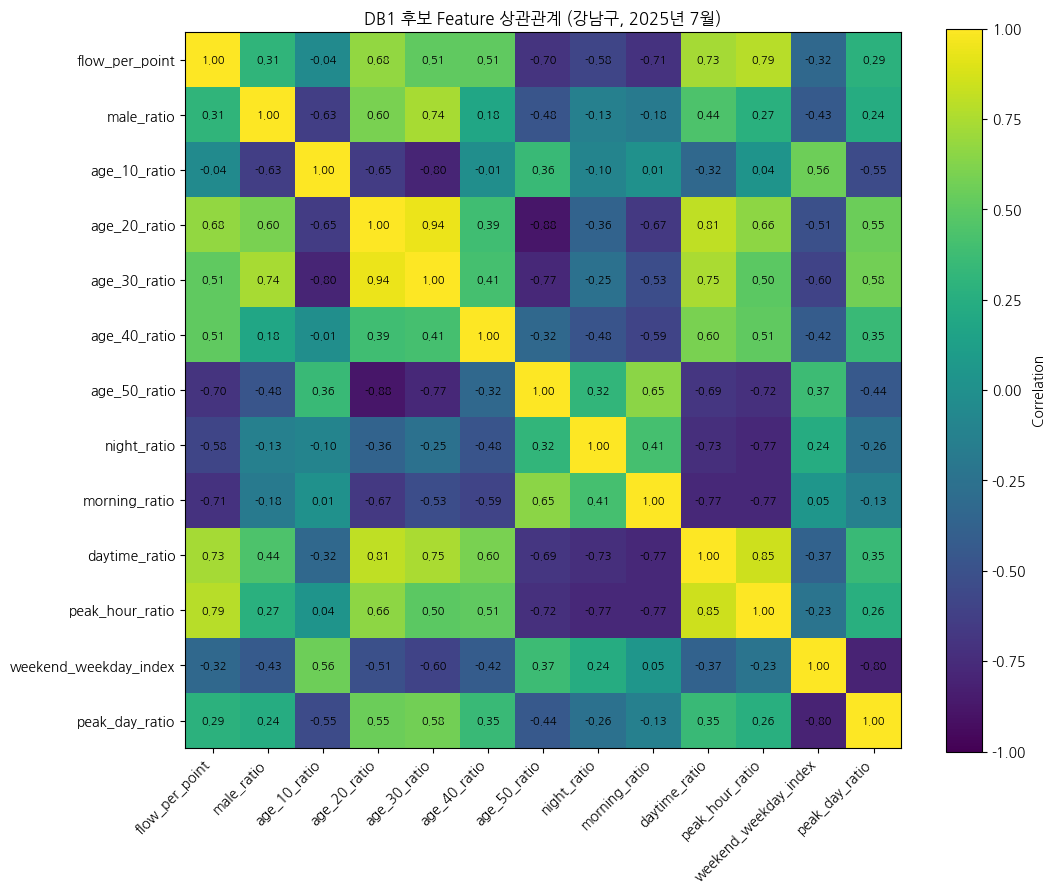

In [54]:
import matplotlib.pyplot as plt
import numpy as np

corr = X_candidate.corr()

fig, ax = plt.subplots(figsize=(11, 9))

im = ax.imshow(
    corr.values,
    vmin=-1,
    vmax=1
)

ax.set_xticks(np.arange(len(candidate_features)))
ax.set_yticks(np.arange(len(candidate_features)))

ax.set_xticklabels(
    candidate_features,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(candidate_features)

# 상관계수 표시
for i in range(len(candidate_features)):
    for j in range(len(candidate_features)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, ax=ax, label="Correlation")

plt.title(
    "DB1 후보 Feature 상관관계 (강남구, 2025년 7월)"
)

plt.tight_layout()
plt.show()

In [55]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ==========================================
# 1. 군집분석에 사용할 Feature
# ==========================================

ml_features = [
    "flow_per_point",
    "male_ratio",
    "age_10_ratio",
    "age_30_ratio",
    "age_50_ratio",
    "daytime_ratio",
    "weekend_weekday_index"
]

X = gangnam_features[ml_features].copy()

print("===== ML Feature =====")
print(ml_features)

print("\n데이터 크기:")
print(X.shape)

print("\n결측치:")
print(X.isna().sum())


# ==========================================
# 2. StandardScaler
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=ml_features,
    index=gangnam_features["dong_name"]
)

print("\n===== 표준화 결과 =====")
print(X_scaled_df.head())

print("\n===== 표준화 후 평균 =====")
print(X_scaled_df.mean().round(4))

print("\n===== 표준화 후 표준편차 =====")
print(X_scaled_df.std(ddof=0).round(4))

===== ML Feature =====
['flow_per_point', 'male_ratio', 'age_10_ratio', 'age_30_ratio', 'age_50_ratio', 'daytime_ratio', 'weekend_weekday_index']

데이터 크기:
(22, 7)

결측치:
flow_per_point           0
male_ratio               0
age_10_ratio             0
age_30_ratio             0
age_50_ratio             0
daytime_ratio            0
weekend_weekday_index    0
dtype: int64

===== 표준화 결과 =====
           flow_per_point  male_ratio  age_10_ratio  age_30_ratio  \
dong_name                                                           
신사동              0.184166   -0.281886     -0.556380      0.599875   
논현1동             0.499085    0.827075     -1.259353      1.565774   
논현2동             0.511397    0.644196     -1.174964      1.475592   
삼성1동             0.921680    0.950865     -0.635817      1.199719   
삼성2동             0.491160    0.819307     -0.619526      0.962490   

           age_50_ratio  daytime_ratio  weekend_weekday_index  
dong_name                                                    

In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# K = 2 ~ 6 비교
# ==========================================

k_values = range(2, 7)

inertias = []
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    inertias.append(
        kmeans.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )


# ==========================================
# 결과표
# ==========================================

cluster_evaluation = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

print("===== 군집 수 평가 =====")
print(cluster_evaluation.to_string(index=False))

===== 군집 수 평가 =====
 k   inertia  silhouette_score
 2 85.204125          0.355944
 3 68.080592          0.340619
 4 52.637259          0.236314
 5 42.083461          0.259632
 6 35.319704          0.242904


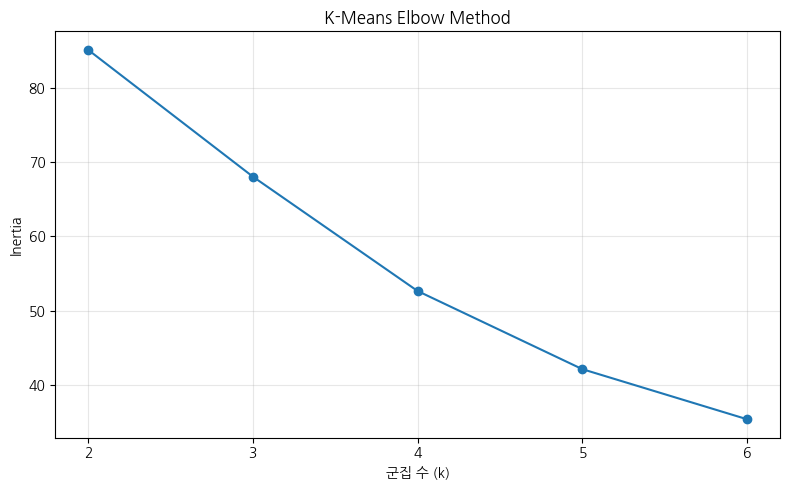

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("군집 수 (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")

plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

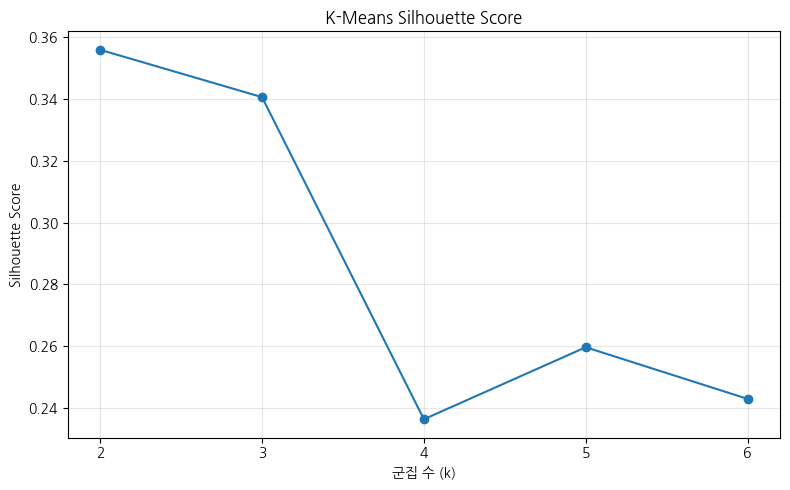

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("군집 수 (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score")

plt.xticks(list(k_values))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
from sklearn.cluster import KMeans
import pandas as pd

comparison = gangnam_features[
    ["adm_cd", "dong_name"]
].copy()

for k in [2, 3]:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    comparison[f"cluster_k{k}"] = (
        model.fit_predict(X_scaled)
    )

print("===== k=2 / k=3 군집 비교 =====")
print(
    comparison
    .sort_values(["cluster_k2", "cluster_k3"])
    .to_string(index=False)
)

print("\n===== 군집별 행정동 수 =====")

for k in [2, 3]:

    print(f"\nk={k}")

    print(
        comparison[f"cluster_k{k}"]
        .value_counts()
        .sort_index()
    )

===== k=2 / k=3 군집 비교 =====
 adm_cd dong_name  cluster_k2  cluster_k3
1123051       신사동           0           0
1123052      논현1동           0           0
1123053      논현2동           0           0
1123058      삼성1동           0           0
1123059      삼성2동           0           0
1123064      역삼1동           0           0
1123065      역삼2동           0           0
1123066      도곡1동           0           0
1123075       수서동           0           0
1123077      압구정동           0           0
1123078       청담동           0           0
1123079      대치2동           0           0
1123063      대치4동           0           2
1123067      도곡2동           1           1
1123068      개포1동           1           1
1123071      개포4동           1           1
1123072      일원본동           1           1
1123073      일원1동           1           1
1123074      일원2동           1           1
1123076       세곡동           1           1
1123080      개포2동           1           1
1123060      대치1동           1           2

=====

In [60]:
for k in [2, 3]:

    label_col = f"cluster_k{k}"

    temp = gangnam_features[
        ["dong_name"] + ml_features
    ].copy()

    temp[label_col] = comparison[label_col].values

    profile = (
        temp
        .groupby(label_col)[ml_features]
        .mean()
        .round(4)
    )

    print(f"\n===== k={k} 군집별 평균 Feature =====")
    print(profile)

    print(f"\n===== k={k} 군집별 행정동 =====")

    for cluster in sorted(temp[label_col].unique()):

        dong_list = temp.loc[
            temp[label_col] == cluster,
            "dong_name"
        ].tolist()

        print(
            f"Cluster {cluster}: "
            + ", ".join(dong_list)
        )


===== k=2 군집별 평균 Feature =====
            flow_per_point  male_ratio  age_10_ratio  age_30_ratio  \
cluster_k2                                                           
0                 721.7635      0.5184        0.0816        0.2017   
1                 326.9858      0.4941        0.1262        0.1350   

            age_50_ratio  daytime_ratio  weekend_weekday_index  
cluster_k2                                                      
0                 0.1704         0.5612                 0.6957  
1                 0.1854         0.5082                 0.8567  

===== k=2 군집별 행정동 =====
Cluster 0: 신사동, 논현1동, 논현2동, 삼성1동, 삼성2동, 대치4동, 역삼1동, 역삼2동, 도곡1동, 수서동, 압구정동, 청담동, 대치2동
Cluster 1: 대치1동, 도곡2동, 개포1동, 개포4동, 일원본동, 일원1동, 일원2동, 세곡동, 개포2동

===== k=3 군집별 평균 Feature =====
            flow_per_point  male_ratio  age_10_ratio  age_30_ratio  \
cluster_k3                                                           
0                 676.1479      0.5194        0.0736        0.2056   
1           

In [61]:
from sklearn.cluster import KMeans

# 최종 K-Means
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

final_labels = final_kmeans.fit_predict(X_scaled)

# 통합 데이터에 군집 추가
gangnam_features["cluster"] = final_labels

# 설명용 군집명
cluster_name_map = {
    0: "고밀도·평일/주간 활동 집중형",
    1: "저밀도·주말 활동 유지형"
}

gangnam_features["cluster_type"] = (
    gangnam_features["cluster"]
    .map(cluster_name_map)
)

print(
    gangnam_features[
        [
            "dong_name",
            "cluster",
            "cluster_type"
        ]
    ]
    .sort_values(["cluster", "dong_name"])
    .to_string(index=False)
)

dong_name  cluster     cluster_type
     논현1동        0 고밀도·평일/주간 활동 집중형
     논현2동        0 고밀도·평일/주간 활동 집중형
     대치2동        0 고밀도·평일/주간 활동 집중형
     대치4동        0 고밀도·평일/주간 활동 집중형
     도곡1동        0 고밀도·평일/주간 활동 집중형
     삼성1동        0 고밀도·평일/주간 활동 집중형
     삼성2동        0 고밀도·평일/주간 활동 집중형
      수서동        0 고밀도·평일/주간 활동 집중형
      신사동        0 고밀도·평일/주간 활동 집중형
     압구정동        0 고밀도·평일/주간 활동 집중형
     역삼1동        0 고밀도·평일/주간 활동 집중형
     역삼2동        0 고밀도·평일/주간 활동 집중형
      청담동        0 고밀도·평일/주간 활동 집중형
     개포1동        1    저밀도·주말 활동 유지형
     개포2동        1    저밀도·주말 활동 유지형
     개포4동        1    저밀도·주말 활동 유지형
     대치1동        1    저밀도·주말 활동 유지형
     도곡2동        1    저밀도·주말 활동 유지형
      세곡동        1    저밀도·주말 활동 유지형
     일원1동        1    저밀도·주말 활동 유지형
     일원2동        1    저밀도·주말 활동 유지형
     일원본동        1    저밀도·주말 활동 유지형


In [62]:
from google.colab import files

output_file = "gangnam_db1_clustered_202507.csv"

gangnam_features.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", output_file)
print("행:", len(gangnam_features))
print("열:", len(gangnam_features.columns))

files.download(output_file)

저장 완료: gangnam_db1_clustered_202507.csv
행: 22
열: 35


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
import geopandas as gpd
import pandas as pd

# 행정동 경계 불러오기
dong_gdf = gpd.read_file(
    "서울_행정동_경계_2017.geojson"
)

# 강남구만 추출
gangnam_boundary = dong_gdf[
    dong_gdf["adm_nm"].str.contains(
        "서울특별시 강남구",
        na=False
    )
].copy()

print("강남구 경계 행정동 수:", len(gangnam_boundary))

# adm_cd 자료형 통일
gangnam_boundary["adm_cd"] = (
    gangnam_boundary["adm_cd"].astype(str)
)

gangnam_features["adm_cd"] = (
    gangnam_features["adm_cd"].astype(str)
)

# 군집 결과 결합
cluster_map = gangnam_boundary.merge(
    gangnam_features[
        [
            "adm_cd",
            "dong_name",
            "cluster",
            "cluster_type"
        ]
    ],
    on="adm_cd",
    how="left"
)

print("\n===== 지도 결합 결과 =====")
print(
    cluster_map[
        [
            "adm_cd",
            "dong_name",
            "cluster",
            "cluster_type"
        ]
    ].to_string(index=False)
)

print(
    "\n군집 미매칭 행정동:",
    cluster_map["cluster"].isna().sum()
)

강남구 경계 행정동 수: 22

===== 지도 결합 결과 =====
 adm_cd dong_name  cluster     cluster_type
1123051       신사동        0 고밀도·평일/주간 활동 집중형
1123052      논현1동        0 고밀도·평일/주간 활동 집중형
1123053      논현2동        0 고밀도·평일/주간 활동 집중형
1123058      삼성1동        0 고밀도·평일/주간 활동 집중형
1123059      삼성2동        0 고밀도·평일/주간 활동 집중형
1123060      대치1동        1    저밀도·주말 활동 유지형
1123063      대치4동        0 고밀도·평일/주간 활동 집중형
1123064      역삼1동        0 고밀도·평일/주간 활동 집중형
1123065      역삼2동        0 고밀도·평일/주간 활동 집중형
1123066      도곡1동        0 고밀도·평일/주간 활동 집중형
1123067      도곡2동        1    저밀도·주말 활동 유지형
1123068      개포1동        1    저밀도·주말 활동 유지형
1123071      개포4동        1    저밀도·주말 활동 유지형
1123072      일원본동        1    저밀도·주말 활동 유지형
1123073      일원1동        1    저밀도·주말 활동 유지형
1123074      일원2동        1    저밀도·주말 활동 유지형
1123075       수서동        0 고밀도·평일/주간 활동 집중형
1123076       세곡동        1    저밀도·주말 활동 유지형
1123077      압구정동        0 고밀도·평일/주간 활동 집중형
1123078       청담동        0 고밀도·평일/주간 활동 집중형
1123079      대치2동        0 고밀도·평일/주간 

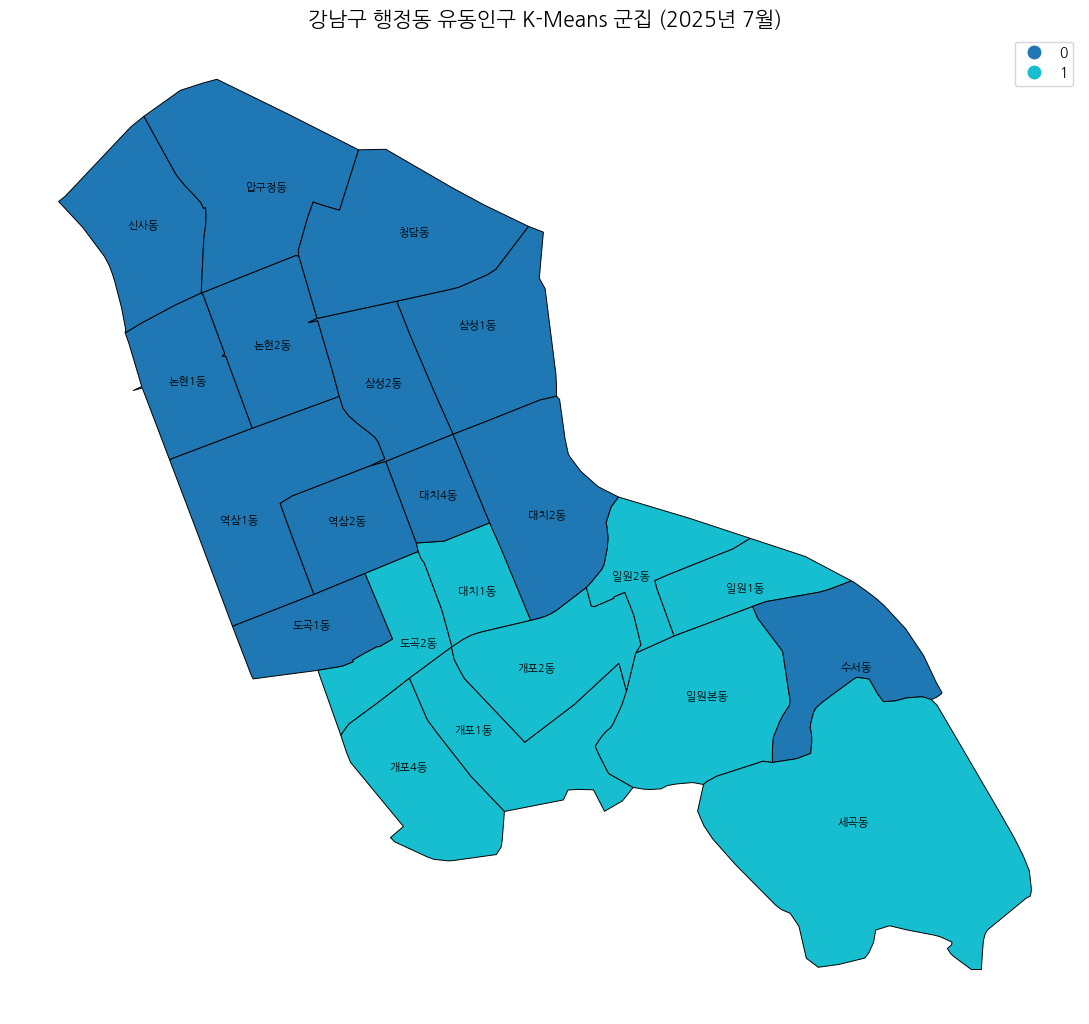

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(11, 11)
)

cluster_map.plot(
    column="cluster",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.7,
    ax=ax
)

# 행정동 이름 표시
for _, row in cluster_map.iterrows():

    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["dong_name"],
        fontsize=8,
        ha="center",
        va="center"
    )

ax.set_title(
    "강남구 행정동 유동인구 K-Means 군집 (2025년 7월)",
    fontsize=15
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

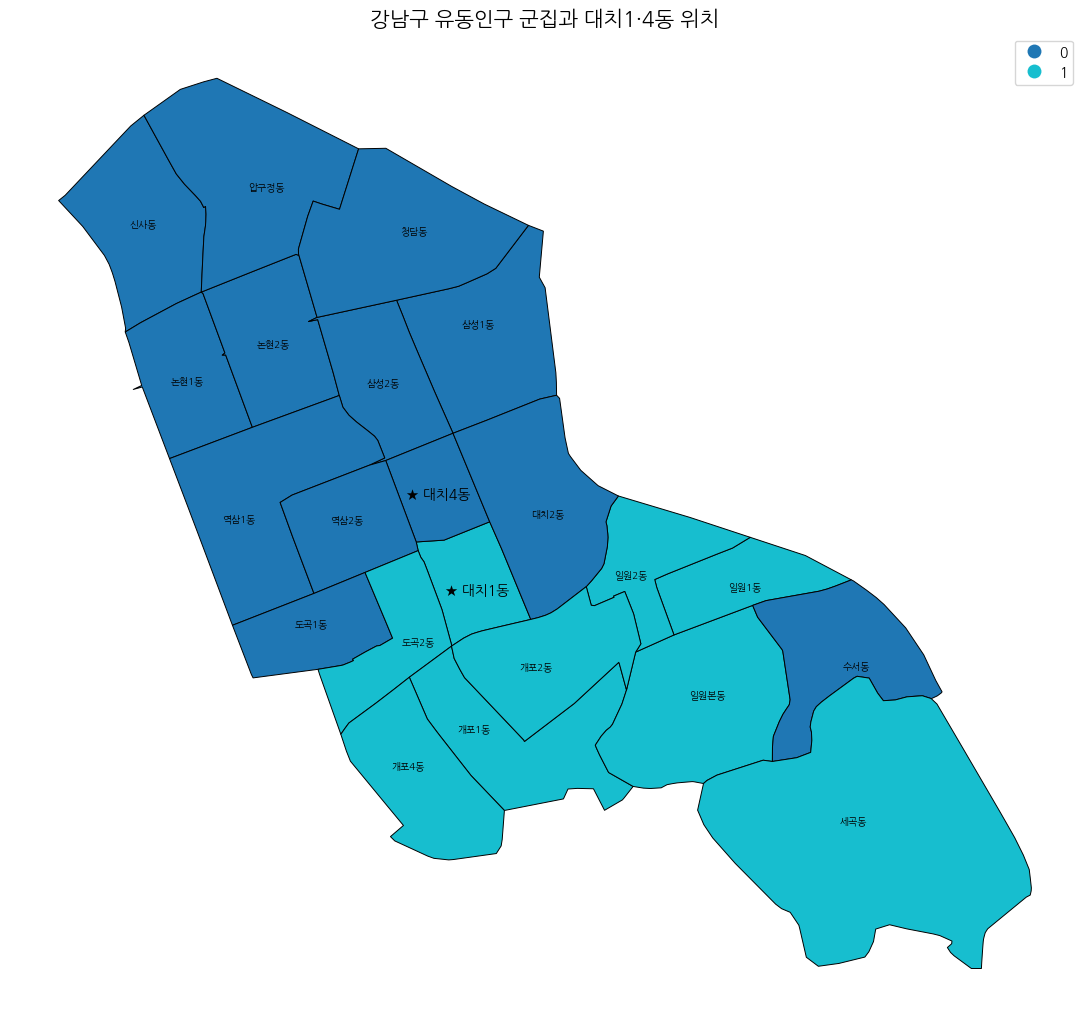

In [65]:
fig, ax = plt.subplots(
    figsize=(11, 11)
)

cluster_map.plot(
    column="cluster",
    categorical=True,
    legend=True,
    edgecolor="black",
    linewidth=0.7,
    ax=ax
)

for _, row in cluster_map.iterrows():

    point = row.geometry.representative_point()

    # 대치1동 / 대치4동 강조
    if row["dong_name"] in ["대치1동", "대치4동"]:

        ax.text(
            point.x,
            point.y,
            "★ " + row["dong_name"],
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center"
        )

    else:

        ax.text(
            point.x,
            point.y,
            row["dong_name"],
            fontsize=7,
            ha="center",
            va="center"
        )

ax.set_title(
    "강남구 유동인구 군집과 대치1·4동 위치",
    fontsize=15
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [66]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np

# 행정동 경계 파일
DONG_FILE = "서울_행정동_경계_2017.geojson"

# 행정동 경계 불러오기
dong_gdf = gpd.read_file(DONG_FILE)

# 좌표계 확인 및 통일
if dong_gdf.crs is None:
    dong_gdf = dong_gdf.set_crs(epsg=4326)
else:
    dong_gdf = dong_gdf.to_crs(epsg=4326)

print("행정동 CRS:", dong_gdf.crs)
print("행정동 수:", len(dong_gdf))

행정동 CRS: EPSG:4326
행정동 수: 424


In [67]:
def convert_coordinates(df):
    """
    EPSG:5179의 X_COORD, Y_COORD를
    EPSG:4326 longitude, latitude로 변환
    """

    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(
            df["X_COORD"],
            df["Y_COORD"]
        ),
        crs="EPSG:5179"
    )

    gdf = gdf.to_crs(epsg=4326)

    result = df.copy()

    result["longitude"] = gdf.geometry.x
    result["latitude"] = gdf.geometry.y

    return result

In [68]:
def extract_gangnam(df, dong_gdf):
    """
    좌표를 행정동과 Spatial Join하고
    강남구 데이터만 추출
    """

    flow_gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(
            df["longitude"],
            df["latitude"]
        ),
        crs="EPSG:4326"
    )

    joined = gpd.sjoin(
        flow_gdf,
        dong_gdf[["adm_cd", "adm_nm", "geometry"]],
        how="left",
        predicate="within"
    )

    # 강남구만 추출
    gangnam = joined[
        joined["adm_nm"].str.contains(
            "강남구",
            na=False
        )
    ].copy()

    gangnam = gangnam.drop(
        columns=["geometry", "index_right"],
        errors="ignore"
    )

    return gangnam

In [69]:
def create_age_features(df):

    male_cols = [
        "MAN_FLOW_POP_CNT_10G",
        "MAN_FLOW_POP_CNT_20G",
        "MAN_FLOW_POP_CNT_30G",
        "MAN_FLOW_POP_CNT_40G",
        "MAN_FLOW_POP_CNT_50G",
        "MAN_FLOW_POP_CNT_60GU"
    ]

    female_cols = [
        "WMAN_FLOW_POP_CNT_10G",
        "WMAN_FLOW_POP_CNT_20G",
        "WMAN_FLOW_POP_CNT_30G",
        "WMAN_FLOW_POP_CNT_40G",
        "WMAN_FLOW_POP_CNT_50G",
        "WMAN_FLOW_POP_CNT_60GU"
    ]

    temp = df.copy()

    temp["male_total"] = temp[male_cols].sum(axis=1)
    temp["female_total"] = temp[female_cols].sum(axis=1)

    temp["age_10"] = (
        temp["MAN_FLOW_POP_CNT_10G"]
        + temp["WMAN_FLOW_POP_CNT_10G"]
    )

    temp["age_20"] = (
        temp["MAN_FLOW_POP_CNT_20G"]
        + temp["WMAN_FLOW_POP_CNT_20G"]
    )

    temp["age_30"] = (
        temp["MAN_FLOW_POP_CNT_30G"]
        + temp["WMAN_FLOW_POP_CNT_30G"]
    )

    temp["age_40"] = (
        temp["MAN_FLOW_POP_CNT_40G"]
        + temp["WMAN_FLOW_POP_CNT_40G"]
    )

    temp["age_50"] = (
        temp["MAN_FLOW_POP_CNT_50G"]
        + temp["WMAN_FLOW_POP_CNT_50G"]
    )

    temp["age_60_plus"] = (
        temp["MAN_FLOW_POP_CNT_60GU"]
        + temp["WMAN_FLOW_POP_CNT_60GU"]
    )

    temp["total_flow"] = (
        temp["male_total"]
        + temp["female_total"]
    )

    # 행정동 집계
    agg_cols = [
        "male_total",
        "female_total",
        "total_flow",
        "age_10",
        "age_20",
        "age_30",
        "age_40",
        "age_50",
        "age_60_plus"
    ]

    result = (
        temp
        .groupby(["adm_cd", "adm_nm"])[agg_cols]
        .sum()
        .reset_index()
    )

    # 포인트 수
    point_count = (
        temp
        .groupby(["adm_cd", "adm_nm"])
        .size()
        .reset_index(name="point_count")
    )

    result = result.merge(
        point_count,
        on=["adm_cd", "adm_nm"]
    )

    # 구성비
    result["flow_per_point"] = (
        result["total_flow"]
        / result["point_count"]
    )

    result["male_ratio"] = (
        result["male_total"]
        / result["total_flow"]
    )

    result["female_ratio"] = (
        result["female_total"]
        / result["total_flow"]
    )

    for age in [
        "age_10",
        "age_20",
        "age_30",
        "age_40",
        "age_50",
        "age_60_plus"
    ]:
        result[f"{age}_ratio"] = (
            result[age]
            / result["total_flow"]
        )

    result["dong_name"] = (
        result["adm_nm"]
        .str.split()
        .str[-1]
    )

    # 7월 최종 Feature Table과 동일하게 정리
    keep_cols = [
        "adm_cd",
        "adm_nm",
        "dong_name",
        "total_flow",
        "point_count",
        "flow_per_point",
        "male_ratio",
        "female_ratio",
        "age_10_ratio",
        "age_20_ratio",
        "age_30_ratio",
        "age_40_ratio",
        "age_50_ratio",
        "age_60_plus_ratio"
    ]

    return result[keep_cols]

In [70]:
age_raw = pd.read_csv("flow_age_pop_202507.csv")

age_wgs84 = convert_coordinates(age_raw)

age_gangnam = extract_gangnam(
    age_wgs84,
    dong_gdf
)

age_features_test = create_age_features(
    age_gangnam
)

print("강남구 원자료:", len(age_gangnam))
print("행정동 수:", age_features_test["adm_cd"].nunique())
print("Feature 크기:", age_features_test.shape)

display(age_features_test.head())

강남구 원자료: 14746
행정동 수: 22
Feature 크기: (22, 14)


,adm_cd,adm_nm,dong_name,total_flow,point_count,flow_per_point,male_ratio,female_ratio,age_10_ratio,age_20_ratio,age_30_ratio,age_40_ratio,age_50_ratio,age_60_plus_ratio
0,1123051,서울특별시 강남구 신사동,신사동,432575.57,699,618.849170,0.503326,0.496674,0.075857,0.167979,0.198433,0.196902,0.171534,0.189296
1,1123052,서울특별시 강남구 논현1동,논현1동,355919.32,495,719.028929,0.523535,0.476465,0.045584,0.196861,0.237137,0.206142,0.156328,0.157949
2,1123053,서울특별시 강남구 논현2동,논현2동,417862.51,578,722.945519,0.520202,0.479798,0.049218,0.177493,0.233524,0.212603,0.162753,0.164409
3,1123058,서울특별시 강남구 삼성1동,삼성1동,626441.05,734,853.461921,0.525791,0.474209,0.072436,0.175119,0.222469,0.213145,0.169965,0.146865
4,1123059,서울특별시 강남구 삼성2동,삼성2동,360403.43,503,716.507813,0.523394,0.476606,0.073137,0.156488,0.212963,0.216359,0.172404,0.168648


In [71]:
def create_time_features(df):
    """
    시간대별 유동인구 데이터를 행정동 단위로 집계하고
    시간대 관련 Feature를 생성
    """

    # 24시간 컬럼
    time_cols = [f"TMST_{h:02d}" for h in range(24)]

    # -------------------------
    # 1. 행정동별 24시간 합계
    # -------------------------
    result = (
        df
        .groupby(["adm_cd", "adm_nm"])[time_cols]
        .sum()
        .reset_index()
    )

    # -------------------------
    # 2. 행정동별 포인트 수
    # -------------------------
    point_count = (
        df
        .groupby(["adm_cd", "adm_nm"])
        .size()
        .reset_index(name="time_point_count")
    )

    result = result.merge(
        point_count,
        on=["adm_cd", "adm_nm"]
    )

    # -------------------------
    # 3. 하루 전체 유동인구
    # -------------------------
    result["time_total"] = result[time_cols].sum(axis=1)

    # 포인트당 평균
    result["time_flow_per_point"] = (
        result["time_total"]
        / result["time_point_count"]
    )

    # -------------------------
    # 4. 시간 구간 정의
    # -------------------------
    night_cols = [
        f"TMST_{h:02d}"
        for h in range(0, 6)
    ]

    morning_cols = [
        f"TMST_{h:02d}"
        for h in range(6, 11)
    ]

    daytime_cols = [
        f"TMST_{h:02d}"
        for h in range(11, 19)
    ]

    evening_cols = [
        f"TMST_{h:02d}"
        for h in range(19, 24)
    ]

    # -------------------------
    # 5. 시간 구간별 비율
    # -------------------------
    result["night_ratio"] = (
        result[night_cols].sum(axis=1)
        / result["time_total"]
    )

    result["morning_ratio"] = (
        result[morning_cols].sum(axis=1)
        / result["time_total"]
    )

    result["daytime_ratio"] = (
        result[daytime_cols].sum(axis=1)
        / result["time_total"]
    )

    result["evening_ratio"] = (
        result[evening_cols].sum(axis=1)
        / result["time_total"]
    )

    # -------------------------
    # 6. Peak Hour
    # -------------------------
    result["peak_hour"] = (
        result[time_cols]
        .idxmax(axis=1)
        .str.replace("TMST_", "")
        .astype(int)
    )

    # 해당 Peak Hour의 실제 유동인구
    peak_values = result[time_cols].max(axis=1)

    result["peak_hour_ratio"] = (
        peak_values
        / result["time_total"]
    )

    # -------------------------
    # 7. 행정동 이름
    # -------------------------
    result["dong_name"] = (
        result["adm_nm"]
        .str.split()
        .str[-1]
    )

    # -------------------------
    # 8. 최종 Feature 선택
    # -------------------------
    keep_cols = [
        "adm_cd",
        "adm_nm",
        "dong_name",
        "time_total",
        "time_point_count",
        "time_flow_per_point",
        "night_ratio",
        "morning_ratio",
        "daytime_ratio",
        "evening_ratio",
        "peak_hour",
        "peak_hour_ratio"
    ]

    return result[keep_cols]

In [72]:
time_raw = pd.read_csv(
    "flow_time_pop_202507.csv"
)

# ① 좌표변환
time_wgs84 = convert_coordinates(
    time_raw
)

# ② 강남구 추출
time_gangnam = extract_gangnam(
    time_wgs84,
    dong_gdf
)

# ③ 시간대 Feature 생성
time_features_test = create_time_features(
    time_gangnam
)

print("===== 시간대 함수 검증 =====")

print(
    "강남구 원자료:",
    f"{len(time_gangnam):,}"
)

print(
    "행정동 수:",
    time_features_test["adm_cd"].nunique()
)

print(
    "Feature 크기:",
    time_features_test.shape
)

display(
    time_features_test.head()
)

===== 시간대 함수 검증 =====
강남구 원자료: 14,746
행정동 수: 22
Feature 크기: (22, 12)


,adm_cd,adm_nm,dong_name,time_total,time_point_count,time_flow_per_point,night_ratio,morning_ratio,daytime_ratio,evening_ratio,peak_hour,peak_hour_ratio
0,1123051,서울특별시 강남구 신사동,신사동,432582.10,699,618.858512,0.045183,0.197944,0.557845,0.199028,18,0.077067
1,1123052,서울특별시 강남구 논현1동,논현1동,355924.12,495,719.038626,0.050251,0.204226,0.552071,0.193453,18,0.078305
2,1123053,서울특별시 강남구 논현2동,논현2동,417866.66,578,722.952699,0.041480,0.213117,0.570003,0.175400,18,0.076990
3,1123058,서울특별시 강남구 삼성1동,삼성1동,626451.36,736,851.156739,0.024986,0.199860,0.620592,0.154562,12,0.082909
4,1123059,서울특별시 강남구 삼성2동,삼성2동,360408.03,503,716.516958,0.039324,0.218743,0.563141,0.178792,18,0.075877


In [73]:
ratio_check = (
    time_features_test["night_ratio"]
    + time_features_test["morning_ratio"]
    + time_features_test["daytime_ratio"]
    + time_features_test["evening_ratio"]
)

print("===== 시간대 비율 합계 검증 =====")
print(ratio_check.round(6).value_counts())

===== 시간대 비율 합계 검증 =====
1.0    22
Name: count, dtype: int64


In [74]:
def create_weekday_features(df):
    """
    요일별 유동인구 데이터를 행정동 단위로 집계하고
    요일 관련 Feature를 생성
    """

    # -------------------------
    # 1. 요일 컬럼 정의
    # -------------------------
    weekday_cols = [
        "FLOW_POP_CNT_MON",
        "FLOW_POP_CNT_TUS",
        "FLOW_POP_CNT_WED",
        "FLOW_POP_CNT_THU",
        "FLOW_POP_CNT_FRI",
        "FLOW_POP_CNT_SAT",
        "FLOW_POP_CNT_SUN"
    ]

    workday_cols = [
        "FLOW_POP_CNT_MON",
        "FLOW_POP_CNT_TUS",
        "FLOW_POP_CNT_WED",
        "FLOW_POP_CNT_THU",
        "FLOW_POP_CNT_FRI"
    ]

    weekend_cols = [
        "FLOW_POP_CNT_SAT",
        "FLOW_POP_CNT_SUN"
    ]

    # -------------------------
    # 2. 행정동별 요일 유동인구 합계
    # -------------------------
    result = (
        df
        .groupby(["adm_cd", "adm_nm"])[weekday_cols]
        .sum()
        .reset_index()
    )

    # -------------------------
    # 3. 행정동별 포인트 수
    # -------------------------
    point_count = (
        df
        .groupby(["adm_cd", "adm_nm"])
        .size()
        .reset_index(name="weekday_point_count")
    )

    result = result.merge(
        point_count,
        on=["adm_cd", "adm_nm"]
    )

    # -------------------------
    # 4. 일주일 전체 유동인구
    # -------------------------
    result["week_total"] = (
        result[weekday_cols].sum(axis=1)
    )

    result["week_flow_per_point"] = (
        result["week_total"]
        / result["weekday_point_count"]
    )

    # -------------------------
    # 5. 평일 / 주말 합계
    # -------------------------
    workday_total = (
        result[workday_cols].sum(axis=1)
    )

    weekend_total = (
        result[weekend_cols].sum(axis=1)
    )

    # 전체 일주일에서 차지하는 비율
    result["workday_ratio"] = (
        workday_total
        / result["week_total"]
    )

    result["weekend_ratio"] = (
        weekend_total
        / result["week_total"]
    )

    # -------------------------
    # 6. 평일/주말 하루 평균 비교
    # -------------------------
    workday_daily_avg = workday_total / 5
    weekend_daily_avg = weekend_total / 2

    result["weekend_weekday_index"] = (
        weekend_daily_avg
        / workday_daily_avg
    )

    # -------------------------
    # 7. 토요일 / 일요일 비율
    # -------------------------
    result["sat_ratio"] = (
        result["FLOW_POP_CNT_SAT"]
        / result["week_total"]
    )

    result["sun_ratio"] = (
        result["FLOW_POP_CNT_SUN"]
        / result["week_total"]
    )

    # -------------------------
    # 8. Peak Day
    # -------------------------
    day_name_map = {
        "FLOW_POP_CNT_MON": "월",
        "FLOW_POP_CNT_TUS": "화",
        "FLOW_POP_CNT_WED": "수",
        "FLOW_POP_CNT_THU": "목",
        "FLOW_POP_CNT_FRI": "금",
        "FLOW_POP_CNT_SAT": "토",
        "FLOW_POP_CNT_SUN": "일"
    }

    peak_col = (
        result[weekday_cols]
        .idxmax(axis=1)
    )

    result["peak_day"] = (
        peak_col.map(day_name_map)
    )

    # 가장 높은 요일의 비중
    result["peak_day_ratio"] = (
        result[weekday_cols].max(axis=1)
        / result["week_total"]
    )

    # -------------------------
    # 9. 행정동 이름
    # -------------------------
    result["dong_name"] = (
        result["adm_nm"]
        .str.split()
        .str[-1]
    )

    # -------------------------
    # 10. 최종 Feature 선택
    # -------------------------
    keep_cols = [
        "adm_cd",
        "adm_nm",
        "dong_name",
        "week_total",
        "weekday_point_count",
        "week_flow_per_point",
        "workday_ratio",
        "weekend_ratio",
        "weekend_weekday_index",
        "sat_ratio",
        "sun_ratio",
        "peak_day",
        "peak_day_ratio"
    ]

    return result[keep_cols]

In [75]:
weekday_raw = pd.read_csv(
    "flow_wkdy_pop_202507.csv"
)

# ① 좌표변환
weekday_wgs84 = convert_coordinates(
    weekday_raw
)

# ② 강남구 추출
weekday_gangnam = extract_gangnam(
    weekday_wgs84,
    dong_gdf
)

# ③ 요일 Feature 생성
weekday_features_test = create_weekday_features(
    weekday_gangnam
)

print("===== 요일 함수 검증 =====")

print(
    "강남구 원자료:",
    f"{len(weekday_gangnam):,}"
)

print(
    "행정동 수:",
    weekday_features_test["adm_cd"].nunique()
)

print(
    "Feature 크기:",
    weekday_features_test.shape
)

display(
    weekday_features_test.head()
)

===== 요일 함수 검증 =====
강남구 원자료: 14,837
행정동 수: 22
Feature 크기: (22, 13)


,adm_cd,adm_nm,dong_name,week_total,weekday_point_count,week_flow_per_point,workday_ratio,weekend_ratio,weekend_weekday_index,sat_ratio,sun_ratio,peak_day,peak_day_ratio
0,1123051,서울특별시 강남구 신사동,신사동,3012676.76,700,4303.823943,0.753631,0.246369,0.817272,0.137825,0.108544,금,0.157919
1,1123052,서울특별시 강남구 논현1동,논현1동,2463533.71,495,4976.835778,0.798194,0.201806,0.632072,0.115970,0.085836,금,0.163926
2,1123053,서울특별시 강남구 논현2동,논현2동,2883583.86,578,4988.899412,0.813927,0.186073,0.571529,0.106701,0.079372,금,0.164533
3,1123058,서울특별시 강남구 삼성1동,삼성1동,4354362.00,761,5721.894875,0.759416,0.240584,0.792002,0.133053,0.107531,금,0.161369
4,1123059,서울특별시 강남구 삼성2동,삼성2동,2486941.03,503,4944.216759,0.814064,0.185936,0.571013,0.104239,0.081697,목,0.164810


In [76]:
print("===== 요일 Feature 검증 =====")

# 1. 평일 + 주말 비율 = 1
ratio_sum = (
    weekday_features_test["workday_ratio"]
    + weekday_features_test["weekend_ratio"]
)

print("\n평일 + 주말 비율:")
print(
    ratio_sum.round(6).value_counts()
)

# 2. Peak Day 분포
print("\nPeak Day 분포:")
print(
    weekday_features_test["peak_day"]
    .value_counts()
)

===== 요일 Feature 검증 =====

평일 + 주말 비율:
1.0    22
Name: count, dtype: int64

Peak Day 분포:
peak_day
금    15
토     3
화     3
목     1
Name: count, dtype: int64


In [77]:
def merge_features(age_features, time_features, weekday_features):
    """
    성·연령 / 시간대 / 요일 Feature Table을
    adm_cd, adm_nm, dong_name 기준으로 통합
    """

    key_cols = [
        "adm_cd",
        "adm_nm",
        "dong_name"
    ]

    # 1. 성·연령 + 시간대
    merged = age_features.merge(
        time_features,
        on=key_cols,
        how="inner"
    )

    # 2. + 요일
    merged = merged.merge(
        weekday_features,
        on=key_cols,
        how="inner"
    )

    # 행정동 코드 순으로 정렬
    merged = (
        merged
        .sort_values("adm_cd")
        .reset_index(drop=True)
    )

    return merged

In [78]:
gangnam_features_test = merge_features(
    age_features_test,
    time_features_test,
    weekday_features_test
)

print("===== 7월 통합 Feature Table 검증 =====")

print(
    "행:",
    len(gangnam_features_test)
)

print(
    "열:",
    len(gangnam_features_test.columns)
)

print(
    "행정동 수:",
    gangnam_features_test["adm_cd"].nunique()
)

print("\n컬럼:")
print(gangnam_features_test.columns.tolist())

print("\n샘플:")
display(gangnam_features_test.head())

===== 7월 통합 Feature Table 검증 =====
행: 22
열: 33
행정동 수: 22

컬럼:
['adm_cd', 'adm_nm', 'dong_name', 'total_flow', 'point_count', 'flow_per_point', 'male_ratio', 'female_ratio', 'age_10_ratio', 'age_20_ratio', 'age_30_ratio', 'age_40_ratio', 'age_50_ratio', 'age_60_plus_ratio', 'time_total', 'time_point_count', 'time_flow_per_point', 'night_ratio', 'morning_ratio', 'daytime_ratio', 'evening_ratio', 'peak_hour', 'peak_hour_ratio', 'week_total', 'weekday_point_count', 'week_flow_per_point', 'workday_ratio', 'weekend_ratio', 'weekend_weekday_index', 'sat_ratio', 'sun_ratio', 'peak_day', 'peak_day_ratio']

샘플:


,adm_cd,adm_nm,dong_name,total_flow,point_count,flow_per_point,male_ratio,female_ratio,age_10_ratio,age_20_ratio,...,week_total,weekday_point_count,week_flow_per_point,workday_ratio,weekend_ratio,weekend_weekday_index,sat_ratio,sun_ratio,peak_day,peak_day_ratio
0,1123051,서울특별시 강남구 신사동,신사동,432575.57,699,618.849170,0.503326,0.496674,0.075857,0.167979,...,3012676.76,700,4303.823943,0.753631,0.246369,0.817272,0.137825,0.108544,금,0.157919
1,1123052,서울특별시 강남구 논현1동,논현1동,355919.32,495,719.028929,0.523535,0.476465,0.045584,0.196861,...,2463533.71,495,4976.835778,0.798194,0.201806,0.632072,0.115970,0.085836,금,0.163926
2,1123053,서울특별시 강남구 논현2동,논현2동,417862.51,578,722.945519,0.520202,0.479798,0.049218,0.177493,...,2883583.86,578,4988.899412,0.813927,0.186073,0.571529,0.106701,0.079372,금,0.164533
3,1123058,서울특별시 강남구 삼성1동,삼성1동,626441.05,734,853.461921,0.525791,0.474209,0.072436,0.175119,...,4354362.00,761,5721.894875,0.759416,0.240584,0.792002,0.133053,0.107531,금,0.161369
4,1123059,서울특별시 강남구 삼성2동,삼성2동,360403.43,503,716.507813,0.523394,0.476606,0.073137,0.156488,...,2486941.03,503,4944.216759,0.814064,0.185936,0.571013,0.104239,0.081697,목,0.164810


In [79]:
print("===== 원천 데이터별 포인트 수 비교 =====")

display(
    gangnam_features_test[
        [
            "dong_name",
            "point_count",
            "time_point_count",
            "weekday_point_count"
        ]
    ]
)

===== 원천 데이터별 포인트 수 비교 =====


,dong_name,point_count,time_point_count,weekday_point_count
0,신사동,699,699,700
1,논현1동,495,495,495
2,논현2동,578,578,578
3,삼성1동,734,736,761
4,삼성2동,503,503,503
5,대치1동,322,322,322
6,대치4동,280,280,280
7,역삼1동,947,947,947
8,역삼2동,447,447,447
9,도곡1동,405,405,405


In [80]:
print("===== 신사동 검증 =====")

check_cols = [
    "dong_name",

    # 성·연령
    "total_flow",
    "point_count",
    "flow_per_point",
    "male_ratio",
    "age_30_ratio",

    # 시간
    "time_total",
    "time_point_count",
    "daytime_ratio",
    "peak_hour",
    "peak_hour_ratio",

    # 요일
    "week_total",
    "weekday_point_count",
    "weekend_weekday_index",
    "peak_day",
    "peak_day_ratio"
]

display(
    gangnam_features_test[
        gangnam_features_test["dong_name"] == "신사동"
    ][check_cols]
)

===== 신사동 검증 =====


,dong_name,total_flow,point_count,flow_per_point,male_ratio,age_30_ratio,time_total,time_point_count,daytime_ratio,peak_hour,peak_hour_ratio,week_total,weekday_point_count,weekend_weekday_index,peak_day,peak_day_ratio
0,신사동,432575.57,699,618.84917,0.503326,0.198433,432582.1,699,0.557845,18,0.077067,3012676.76,700,0.817272,금,0.157919


In [82]:
def process_month(
    age_file,
    time_file,
    weekday_file,
    dong_gdf,
    output_file=None
):
    """
    한 달치 DB1 유동인구 데이터 3종을 자동 처리한다.

    처리 과정:
    1. CSV 로드
    2. EPSG:5179 → EPSG:4326 좌표변환
    3. 행정동 Spatial Join 및 강남구 추출
    4. 성·연령 Feature 생성
    5. 시간대 Feature 생성
    6. 요일 Feature 생성
    7. 행정동 단위 통합
    8. 선택적으로 CSV 저장
    """

    print("=" * 50)
    print("DB1 월별 데이터 처리 시작")
    print("=" * 50)

    # --------------------------------
    # 1. 원본 데이터 불러오기
    # --------------------------------
    print("\n[1/5] 원본 데이터 불러오기")

    age_raw = pd.read_csv(age_file)
    time_raw = pd.read_csv(time_file)
    weekday_raw = pd.read_csv(weekday_file)

    print(f"성·연령 : {len(age_raw):,}행")
    print(f"시간대  : {len(time_raw):,}행")
    print(f"요일    : {len(weekday_raw):,}행")

    # --------------------------------
    # 2. 좌표 변환
    # --------------------------------
    print("\n[2/5] 좌표 변환")

    age_wgs84 = convert_coordinates(age_raw)
    time_wgs84 = convert_coordinates(time_raw)
    weekday_wgs84 = convert_coordinates(weekday_raw)

    print("좌표 변환 완료")

    # --------------------------------
    # 3. 강남구 추출
    # --------------------------------
    print("\n[3/5] 강남구 Spatial Join")

    age_gangnam = extract_gangnam(
        age_wgs84,
        dong_gdf
    )

    time_gangnam = extract_gangnam(
        time_wgs84,
        dong_gdf
    )

    weekday_gangnam = extract_gangnam(
        weekday_wgs84,
        dong_gdf
    )

    print(f"성·연령 : {len(age_gangnam):,}행")
    print(f"시간대  : {len(time_gangnam):,}행")
    print(f"요일    : {len(weekday_gangnam):,}행")

    # --------------------------------
    # 4. Feature 생성
    # --------------------------------
    print("\n[4/5] Feature 생성")

    age_features = create_age_features(
        age_gangnam
    )

    time_features = create_time_features(
        time_gangnam
    )

    weekday_features = create_weekday_features(
        weekday_gangnam
    )

    print(
        f"성·연령 Feature : {age_features.shape}"
    )

    print(
        f"시간대 Feature  : {time_features.shape}"
    )

    print(
        f"요일 Feature    : {weekday_features.shape}"
    )

    # --------------------------------
    # 5. Feature 통합
    # --------------------------------
    print("\n[5/5] Feature 통합")

    final_features = merge_features(
        age_features,
        time_features,
        weekday_features
    )

    print(
        f"최종 데이터 : {final_features.shape}"
    )

    print(
        "행정동 수:",
        final_features["adm_cd"].nunique()
    )

    # --------------------------------
    # CSV 저장
    # --------------------------------
    if output_file is not None:

        final_features.to_csv(
            output_file,
            index=False,
            encoding="utf-8-sig"
        )

        print(
            f"\n저장 완료: {output_file}"
        )

    print("\n처리 완료!")

    return final_features

In [84]:
features_202507 = process_month(
    age_file="flow_age_pop_202507.csv",
    time_file="flow_time_pop_202507.csv",
    weekday_file="flow_wkdy_pop_202507.csv",
    dong_gdf=dong_gdf,
    output_file="gangnam_db1_features_202507_auto.csv"
)

DB1 월별 데이터 처리 시작

[1/5] 원본 데이터 불러오기
성·연령 : 98,129행
시간대  : 94,099행
요일    : 117,825행

[2/5] 좌표 변환
좌표 변환 완료

[3/5] 강남구 Spatial Join
성·연령 : 14,746행
시간대  : 14,746행
요일    : 14,837행

[4/5] Feature 생성
성·연령 Feature : (22, 14)
시간대 Feature  : (22, 12)
요일 Feature    : (22, 13)

[5/5] Feature 통합
최종 데이터 : (22, 33)
행정동 수: 22

저장 완료: gangnam_db1_features_202507_auto.csv

처리 완료!


In [85]:
features_202508 = process_month(
    age_file="flow_age_pop_202508.csv",
    time_file="flow_time_pop_202508.csv",
    weekday_file="flow_wkdy_pop_202508.csv",
    dong_gdf=dong_gdf,
    output_file="gangnam_db1_features_202508.csv"
)

DB1 월별 데이터 처리 시작

[1/5] 원본 데이터 불러오기
성·연령 : 99,115행
시간대  : 95,374행
요일    : 118,958행

[2/5] 좌표 변환
좌표 변환 완료

[3/5] 강남구 Spatial Join
성·연령 : 14,791행
시간대  : 14,794행
요일    : 14,878행

[4/5] Feature 생성
성·연령 Feature : (22, 14)
시간대 Feature  : (22, 12)
요일 Feature    : (22, 13)

[5/5] Feature 통합
최종 데이터 : (22, 33)
행정동 수: 22

저장 완료: gangnam_db1_features_202508.csv

처리 완료!


In [86]:
features_202509 = process_month(
    age_file="flow_age_pop_202509.csv",
    time_file="flow_time_pop_202509.csv",
    weekday_file="flow_wkdy_pop_202509.csv",
    dong_gdf=dong_gdf,
    output_file="gangnam_db1_features_202509.csv"
)

DB1 월별 데이터 처리 시작

[1/5] 원본 데이터 불러오기
성·연령 : 99,469행
시간대  : 95,084행
요일    : 119,865행

[2/5] 좌표 변환
좌표 변환 완료

[3/5] 강남구 Spatial Join
성·연령 : 14,830행
시간대  : 14,829행
요일    : 14,905행

[4/5] Feature 생성
성·연령 Feature : (22, 14)
시간대 Feature  : (22, 12)
요일 Feature    : (22, 13)

[5/5] Feature 통합
최종 데이터 : (22, 33)
행정동 수: 22

저장 완료: gangnam_db1_features_202509.csv

처리 완료!


In [87]:
months = [
    "202508",
    "202509",
    "202510",
    "202511",
    "202512"
]

monthly_features = {}

for month in months:

    print("\n")
    print("#" * 60)
    print(f"{month} 처리")
    print("#" * 60)

    features = process_month(
        age_file=f"flow_age_pop_{month}.csv",
        time_file=f"flow_time_pop_{month}.csv",
        weekday_file=f"flow_wkdy_pop_{month}.csv",
        dong_gdf=dong_gdf,
        output_file=f"gangnam_db1_features_{month}.csv"
    )

    # 월 정보 추가
    features["STD_YM"] = month

    monthly_features[month] = features



############################################################
202508 처리
############################################################
DB1 월별 데이터 처리 시작

[1/5] 원본 데이터 불러오기
성·연령 : 99,115행
시간대  : 95,374행
요일    : 118,958행

[2/5] 좌표 변환
좌표 변환 완료

[3/5] 강남구 Spatial Join
성·연령 : 14,791행
시간대  : 14,794행
요일    : 14,878행

[4/5] Feature 생성
성·연령 Feature : (22, 14)
시간대 Feature  : (22, 12)
요일 Feature    : (22, 13)

[5/5] Feature 통합
최종 데이터 : (22, 33)
행정동 수: 22

저장 완료: gangnam_db1_features_202508.csv

처리 완료!


############################################################
202509 처리
############################################################
DB1 월별 데이터 처리 시작

[1/5] 원본 데이터 불러오기
성·연령 : 99,469행
시간대  : 95,084행
요일    : 119,865행

[2/5] 좌표 변환
좌표 변환 완료

[3/5] 강남구 Spatial Join
성·연령 : 14,830행
시간대  : 14,829행
요일    : 14,905행

[4/5] Feature 생성
성·연령 Feature : (22, 14)
시간대 Feature  : (22, 12)
요일 Feature    : (22, 13)

[5/5] Feature 통합
최종 데이터 : (22, 33)
행정동 수: 22

저장 완료: gangnam_db1_features_202509.csv

처리 완료!


##########

/tmp/ipykernel_2696/778759117.py:32: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  time_raw = pd.read_csv(time_file)


성·연령 : 98,345행
시간대  : 185,090행
요일    : 242,534행

[2/5] 좌표 변환
좌표 변환 완료

[3/5] 강남구 Spatial Join
성·연령 : 14,883행
시간대  : 29,788행
요일    : 29,946행

[4/5] Feature 생성
성·연령 Feature : (22, 14)
시간대 Feature  : (22, 12)
요일 Feature    : (22, 13)

[5/5] Feature 통합
최종 데이터 : (22, 33)
행정동 수: 22

저장 완료: gangnam_db1_features_202512.csv

처리 완료!


In [88]:
for month, df in monthly_features.items():

    print(
        month,
        "shape =", df.shape,
        "| 행정동 =", df["adm_cd"].nunique()
    )

202508 shape = (22, 34) | 행정동 = 22
202509 shape = (22, 34) | 행정동 = 22
202510 shape = (22, 34) | 행정동 = 22
202511 shape = (22, 34) | 행정동 = 22
202512 shape = (22, 34) | 행정동 = 22


In [89]:
features_202507["STD_YM"] = "202507"

all_months = [
    features_202507,
    monthly_features["202508"],
    monthly_features["202509"],
    monthly_features["202510"],
    monthly_features["202511"],
    monthly_features["202512"]
]

gangnam_panel = pd.concat(
    all_months,
    ignore_index=True
)

print(gangnam_panel.shape)
print(gangnam_panel["STD_YM"].value_counts().sort_index())

(132, 34)
STD_YM
202507    22
202508    22
202509    22
202510    22
202511    22
202512    22
Name: count, dtype: int64


In [90]:
cluster_features = [
    "flow_per_point",
    "male_ratio",
    "age_10_ratio",
    "age_30_ratio",
    "age_50_ratio",
    "daytime_ratio",
    "weekend_weekday_index"
]

In [91]:
X = gangnam_panel[cluster_features].copy()

print("X shape:", X.shape)
print("\n결측값:")
print(X.isnull().sum())

print("\n기초통계:")
display(X.describe())

X shape: (132, 7)

결측값:
flow_per_point           0
male_ratio               0
age_10_ratio             0
age_30_ratio             0
age_50_ratio             0
daytime_ratio            0
weekend_weekday_index    0
dtype: int64

기초통계:


,flow_per_point,male_ratio,age_10_ratio,age_30_ratio,age_50_ratio,daytime_ratio,weekend_weekday_index
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
mean,547.868510,0.506550,0.101344,0.173896,0.175934,0.546539,0.778553
std,313.564995,0.017779,0.042766,0.039507,0.010291,0.031114,0.150138
min,81.976035,0.466928,0.042220,0.098424,0.151988,0.488892,0.536574
25%,317.831933,0.495705,0.068039,0.144361,0.171191,0.519538,0.660622
50%,538.718510,0.510782,0.098763,0.166896,0.175594,0.552275,0.754280
75%,717.138092,0.519527,0.125637,0.206980,0.182101,0.567458,0.866216
max,1332.829683,0.536103,0.229821,0.243642,0.196227,0.633906,1.133138


In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

print(
    "평균:",
    X_scaled.mean(axis=0).round(4)
)

print(
    "표준편차:",
    X_scaled.std(axis=0).round(4)
)

Scaled shape: (132, 7)
평균: [-0.  0. -0. -0. -0.  0.  0.]
표준편차: [1. 1. 1. 1. 1. 1. 1.]


In [93]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(
            X_scaled,
            labels
        )
    })

cluster_test = pd.DataFrame(results)

display(cluster_test)

,k,inertia,silhouette
0,2,527.545630,0.381479
1,3,419.499731,0.361103
2,4,328.117008,0.328584
3,5,263.993505,0.375154
4,6,224.061672,0.396448


In [94]:
from google.colab import files

uploaded = files.upload()

print("\n===== 업로드된 파일 =====")
for filename in uploaded.keys():
    print(filename)

Saving flow_age_pop_202508_wgs84.csv to flow_age_pop_202508_wgs84.csv
Saving flow_age_pop_202509_wgs84.csv to flow_age_pop_202509_wgs84.csv
Saving flow_age_pop_202510_wgs84.csv to flow_age_pop_202510_wgs84.csv
Saving flow_age_pop_202511_wgs84.csv to flow_age_pop_202511_wgs84.csv
Saving flow_age_pop_202512_wgs84.csv to flow_age_pop_202512_wgs84.csv
Saving flow_time_pop_202508_wgs84.csv to flow_time_pop_202508_wgs84.csv
Saving flow_time_pop_202509_wgs84.csv to flow_time_pop_202509_wgs84.csv
Saving flow_time_pop_202510_wgs84.csv to flow_time_pop_202510_wgs84.csv
Saving flow_time_pop_202511_wgs84.csv to flow_time_pop_202511_wgs84.csv
Saving flow_time_pop_202512_wgs84.csv to flow_time_pop_202512_wgs84.csv
Saving flow_wkdy_pop_202508_wgs84.csv to flow_wkdy_pop_202508_wgs84.csv
Saving flow_wkdy_pop_202509_wgs84.csv to flow_wkdy_pop_202509_wgs84.csv
Saving flow_wkdy_pop_202510_wgs84.csv to flow_wkdy_pop_202510_wgs84.csv
Saving flow_wkdy_pop_202511_wgs84.csv to flow_wkdy_pop_202511_wgs84.csv
Sa

In [95]:
def process_month_wgs84(
    age_file,
    time_file,
    weekday_file,
    dong_gdf,
    output_file=None
):
    """
    이미 longitude, latitude가 존재하는 WGS84 파일용 월별 처리 함수

    1. CSV 로드
    2. 강남구 Spatial Join
    3. Feature 생성
    4. Feature 통합
    5. CSV 저장
    """

    print("=" * 60)
    print("DB1 WGS84 월별 데이터 처리 시작")
    print("=" * 60)

    # 1. 파일 읽기
    age_raw = pd.read_csv(age_file)
    time_raw = pd.read_csv(time_file)
    weekday_raw = pd.read_csv(weekday_file)

    print("\n[1/4] 원본 데이터")
    print(f"성·연령 : {len(age_raw):,}행")
    print(f"시간대  : {len(time_raw):,}행")
    print(f"요일    : {len(weekday_raw):,}행")

    # 좌표 컬럼 확인
    for name, df in {
        "age": age_raw,
        "time": time_raw,
        "weekday": weekday_raw
    }.items():

        if not {"longitude", "latitude"}.issubset(df.columns):
            raise ValueError(
                f"{name} 파일에 longitude/latitude가 없습니다."
            )

    print("\n[2/4] 강남구 Spatial Join")

    age_gangnam = extract_gangnam(age_raw, dong_gdf)
    time_gangnam = extract_gangnam(time_raw, dong_gdf)
    weekday_gangnam = extract_gangnam(weekday_raw, dong_gdf)

    print(f"성·연령 : {len(age_gangnam):,}행")
    print(f"시간대  : {len(time_gangnam):,}행")
    print(f"요일    : {len(weekday_gangnam):,}행")

    # 3. Feature 생성
    print("\n[3/4] Feature 생성")

    age_features = create_age_features(age_gangnam)
    time_features = create_time_features(time_gangnam)
    weekday_features = create_weekday_features(weekday_gangnam)

    print(f"성·연령 : {age_features.shape}")
    print(f"시간대  : {time_features.shape}")
    print(f"요일    : {weekday_features.shape}")

    # 4. 통합
    print("\n[4/4] Feature 통합")

    final_features = merge_features(
        age_features,
        time_features,
        weekday_features
    )

    print("최종 크기:", final_features.shape)
    print(
        "행정동 수:",
        final_features["adm_cd"].nunique()
    )

    if output_file is not None:
        final_features.to_csv(
            output_file,
            index=False,
            encoding="utf-8-sig"
        )

        print(f"\n저장 완료: {output_file}")

    return final_features

In [96]:
months = [
    "202508",
    "202509",
    "202510",
    "202511",
    "202512"
]

monthly_features = {}

for month in months:

    print("\n\n")
    print("#" * 60)
    print(f"{month} 처리")
    print("#" * 60)

    features = process_month_wgs84(
        age_file=f"flow_age_pop_{month}_wgs84.csv",
        time_file=f"flow_time_pop_{month}_wgs84.csv",
        weekday_file=f"flow_wkdy_pop_{month}_wgs84.csv",
        dong_gdf=dong_gdf,
        output_file=f"gangnam_db1_features_{month}.csv"
    )

    features["STD_YM"] = month

    monthly_features[month] = features




############################################################
202508 처리
############################################################
DB1 WGS84 월별 데이터 처리 시작

[1/4] 원본 데이터
성·연령 : 99,115행
시간대  : 95,374행
요일    : 118,958행

[2/4] 강남구 Spatial Join
성·연령 : 14,791행
시간대  : 14,794행
요일    : 14,878행

[3/4] Feature 생성
성·연령 : (22, 14)
시간대  : (22, 12)
요일    : (22, 13)

[4/4] Feature 통합
최종 크기: (22, 33)
행정동 수: 22

저장 완료: gangnam_db1_features_202508.csv



############################################################
202509 처리
############################################################
DB1 WGS84 월별 데이터 처리 시작

[1/4] 원본 데이터
성·연령 : 99,469행
시간대  : 95,084행
요일    : 119,865행

[2/4] 강남구 Spatial Join
성·연령 : 14,830행
시간대  : 14,829행
요일    : 14,905행

[3/4] Feature 생성
성·연령 : (22, 14)
시간대  : (22, 12)
요일    : (22, 13)

[4/4] Feature 통합
최종 크기: (22, 33)
행정동 수: 22

저장 완료: gangnam_db1_features_202509.csv



############################################################
202510 처리
##############################################

/tmp/ipykernel_2696/3853911316.py:24: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  time_raw = pd.read_csv(time_file)



[1/4] 원본 데이터
성·연령 : 98,345행
시간대  : 185,090행
요일    : 242,534행

[2/4] 강남구 Spatial Join
성·연령 : 14,883행
시간대  : 29,788행
요일    : 29,946행

[3/4] Feature 생성
성·연령 : (22, 14)
시간대  : (22, 12)
요일    : (22, 13)

[4/4] Feature 통합
최종 크기: (22, 33)
행정동 수: 22

저장 완료: gangnam_db1_features_202512.csv


In [97]:
print("===== 월별 처리 결과 =====")

for month, df in monthly_features.items():

    print(
        month,
        "| shape:", df.shape,
        "| 행정동:", df["adm_cd"].nunique(),
        "| 결측값:", df.isnull().sum().sum()
    )

===== 월별 처리 결과 =====
202508 | shape: (22, 34) | 행정동: 22 | 결측값: 0
202509 | shape: (22, 34) | 행정동: 22 | 결측값: 0
202510 | shape: (22, 34) | 행정동: 22 | 결측값: 0
202511 | shape: (22, 34) | 행정동: 22 | 결측값: 0
202512 | shape: (22, 34) | 행정동: 22 | 결측값: 0


In [98]:
features_202507["STD_YM"] = "202507"

print(features_202507.shape)
print(features_202507["STD_YM"].value_counts())

(22, 34)
STD_YM
202507    22
Name: count, dtype: int64


In [99]:
all_months = [
    features_202507,
    monthly_features["202508"],
    monthly_features["202509"],
    monthly_features["202510"],
    monthly_features["202511"],
    monthly_features["202512"]
]

gangnam_panel = pd.concat(
    all_months,
    ignore_index=True
)

print("패널 크기:", gangnam_panel.shape)

print("\n월별 행 수:")
print(
    gangnam_panel["STD_YM"]
    .value_counts()
    .sort_index()
)

print(
    "\n행정동 수:",
    gangnam_panel["adm_cd"].nunique()
)

print(
    "전체 결측값:",
    gangnam_panel.isnull().sum().sum()
)

패널 크기: (132, 34)

월별 행 수:
STD_YM
202507    22
202508    22
202509    22
202510    22
202511    22
202512    22
Name: count, dtype: int64

행정동 수: 22
전체 결측값: 0


In [100]:
dong_month_check = (
    gangnam_panel
    .groupby(["adm_cd", "dong_name"])
    ["STD_YM"]
    .nunique()
    .reset_index(name="month_count")
)

display(dong_month_check)

print("\n월 수 분포:")
print(
    dong_month_check["month_count"]
    .value_counts()
)

,adm_cd,dong_name,month_count
0,1123051,신사동,6
1,1123052,논현1동,6
2,1123053,논현2동,6
3,1123058,삼성1동,6
4,1123059,삼성2동,6
5,1123060,대치1동,6
6,1123063,대치4동,6
7,1123064,역삼1동,6
8,1123065,역삼2동,6
9,1123066,도곡1동,6



월 수 분포:
month_count
6    22
Name: count, dtype: int64


In [101]:
analysis_features = [
    "flow_per_point",
    "male_ratio",
    "age_10_ratio",
    "age_30_ratio",
    "age_50_ratio",
    "daytime_ratio",
    "weekend_weekday_index"
]

monthly_mean = (
    gangnam_panel
    .groupby("STD_YM")[analysis_features]
    .mean()
    .reset_index()
)

display(monthly_mean)

,STD_YM,flow_per_point,male_ratio,age_10_ratio,age_30_ratio,age_50_ratio,daytime_ratio,weekend_weekday_index
0,202507,560.263514,0.508463,0.099816,0.174396,0.176563,0.539498,0.761541
1,202508,535.026793,0.506585,0.103921,0.173300,0.175745,0.540071,0.760534
2,202509,563.760474,0.506296,0.098445,0.176331,0.177036,0.543482,0.788249
3,202510,532.701480,0.505269,0.101567,0.173046,0.176081,0.548793,0.794929
4,202511,554.093825,0.505545,0.102053,0.174315,0.174634,0.552166,0.783646
5,202512,541.364974,0.507140,0.102261,0.171988,0.175547,0.555220,0.782422


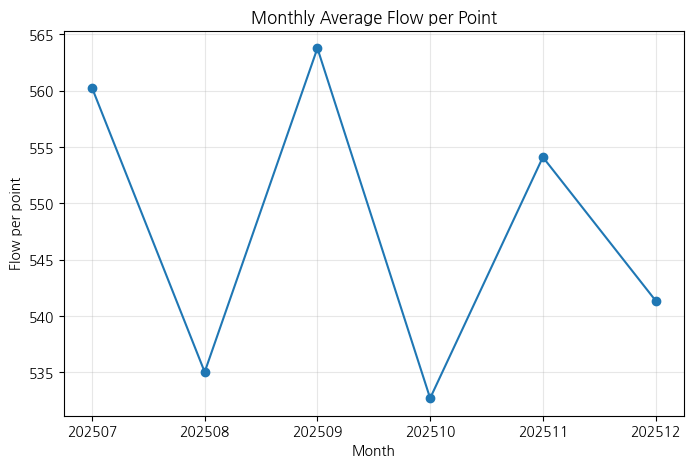

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    monthly_mean["STD_YM"],
    monthly_mean["flow_per_point"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Flow per point")
plt.title("Monthly Average Flow per Point")

plt.grid(alpha=0.3)
plt.show()

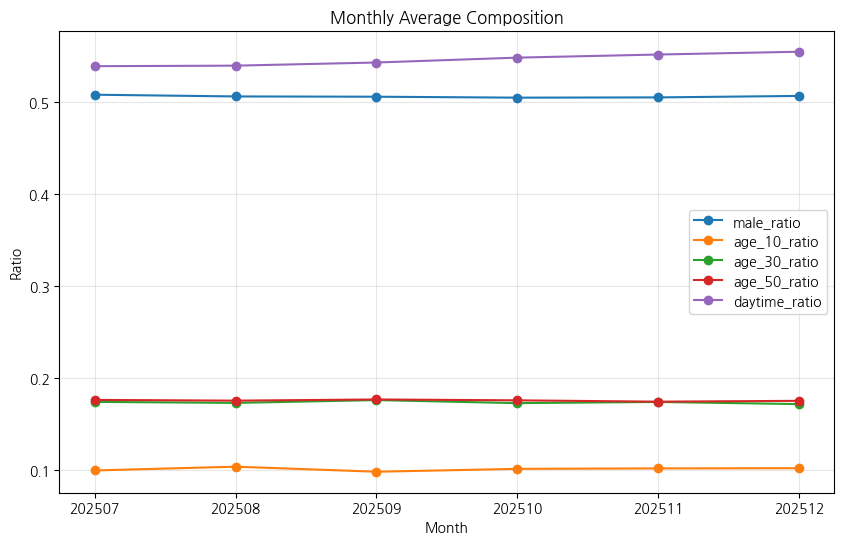

In [103]:
ratio_features = [
    "male_ratio",
    "age_10_ratio",
    "age_30_ratio",
    "age_50_ratio",
    "daytime_ratio"
]

plt.figure(figsize=(10, 6))

for col in ratio_features:
    plt.plot(
        monthly_mean["STD_YM"],
        monthly_mean[col],
        marker="o",
        label=col
    )

plt.xlabel("Month")
plt.ylabel("Ratio")
plt.title("Monthly Average Composition")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

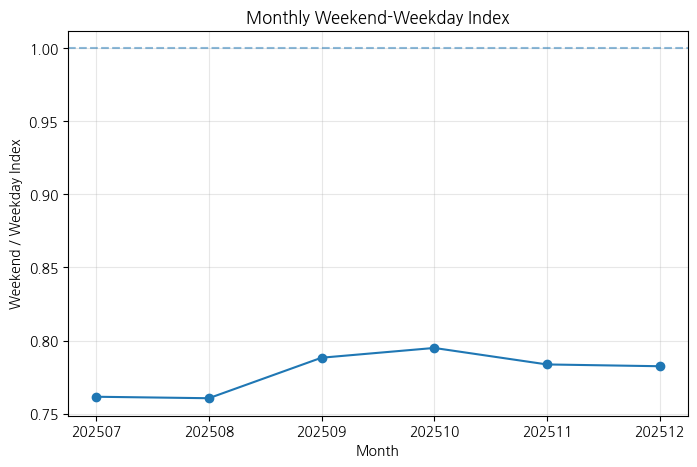

In [104]:
plt.figure(figsize=(8, 5))

plt.plot(
    monthly_mean["STD_YM"],
    monthly_mean["weekend_weekday_index"],
    marker="o"
)

plt.axhline(
    y=1,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Month")
plt.ylabel("Weekend / Weekday Index")
plt.title("Monthly Weekend-Weekday Index")

plt.grid(alpha=0.3)
plt.show()

In [105]:
cluster_features = [
    "flow_per_point",
    "male_ratio",
    "age_10_ratio",
    "age_30_ratio",
    "age_50_ratio",
    "daytime_ratio",
    "weekend_weekday_index"
]

X = gangnam_panel[cluster_features].copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("X shape:", X.shape)

print("\n결측값:")
print(X.isnull().sum())

print("\n표준화 평균:")
print(X_scaled.mean(axis=0).round(4))

print("\n표준화 표준편차:")
print(X_scaled.std(axis=0).round(4))

X shape: (132, 7)

결측값:
flow_per_point           0
male_ratio               0
age_10_ratio             0
age_30_ratio             0
age_50_ratio             0
daytime_ratio            0
weekend_weekday_index    0
dtype: int64

표준화 평균:
[-0.  0. -0. -0. -0.  0.  0.]

표준화 표준편차:
[1. 1. 1. 1. 1. 1. 1.]


In [106]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(
            X_scaled,
            labels
        )
    })

cluster_test = pd.DataFrame(results)

display(cluster_test)

,k,inertia,silhouette
0,2,527.545630,0.381479
1,3,419.499731,0.361103
2,4,328.117008,0.328584
3,5,263.993505,0.375154
4,6,224.061672,0.396448


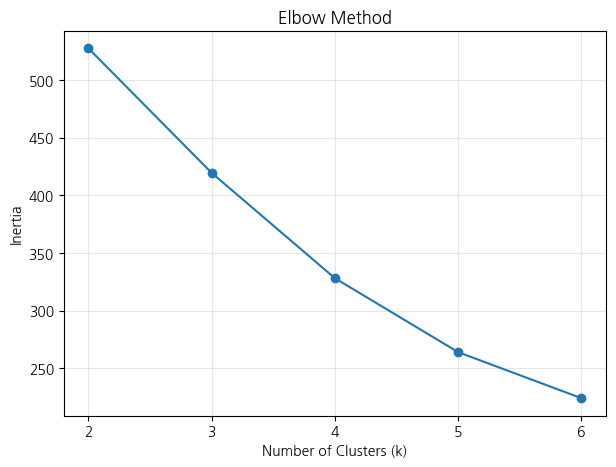

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    cluster_test["k"],
    cluster_test["inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(cluster_test["k"])
plt.grid(alpha=0.3)

plt.show()

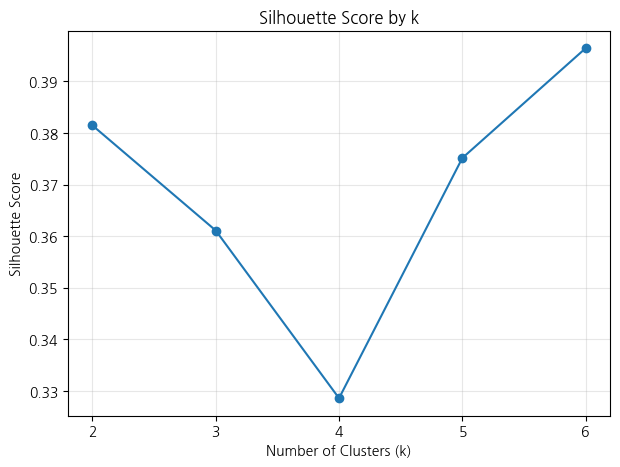

In [108]:
plt.figure(figsize=(7, 5))

plt.plot(
    cluster_test["k"],
    cluster_test["silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by k")

plt.xticks(cluster_test["k"])
plt.grid(alpha=0.3)

plt.show()

In [109]:
from sklearn.cluster import KMeans

kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

kmeans_6 = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=20
)

gangnam_panel["cluster_k2"] = (
    kmeans_2.fit_predict(X_scaled)
)

gangnam_panel["cluster_k6"] = (
    kmeans_6.fit_predict(X_scaled)
)

In [110]:
print("===== k=2 =====")
print(
    gangnam_panel["cluster_k2"]
    .value_counts()
    .sort_index()
)

print("\n===== k=6 =====")
print(
    gangnam_panel["cluster_k6"]
    .value_counts()
    .sort_index()
)

===== k=2 =====
cluster_k2
0    54
1    78
Name: count, dtype: int64

===== k=6 =====
cluster_k6
0    12
1    42
2    24
3    18
4    30
5     6
Name: count, dtype: int64


In [111]:
print("===== k=2 월별 분포 =====")

display(
    pd.crosstab(
        gangnam_panel["STD_YM"],
        gangnam_panel["cluster_k2"]
    )
)

print("===== k=6 월별 분포 =====")

display(
    pd.crosstab(
        gangnam_panel["STD_YM"],
        gangnam_panel["cluster_k6"]
    )
)

===== k=2 월별 분포 =====


cluster_k2,0,1
STD_YM,,
202507,9,13
202508,9,13
202509,9,13
202510,9,13
202511,9,13
202512,9,13


===== k=6 월별 분포 =====


cluster_k6,0,1,2,3,4,5
STD_YM,,,,,,
202507,2,7,4,3,5,1
202508,2,7,4,3,5,1
202509,2,7,4,3,5,1
202510,2,7,4,3,5,1
202511,2,7,4,3,5,1
202512,2,7,4,3,5,1


In [112]:
k2_transition = gangnam_panel.pivot(
    index="dong_name",
    columns="STD_YM",
    values="cluster_k2"
)

k6_transition = gangnam_panel.pivot(
    index="dong_name",
    columns="STD_YM",
    values="cluster_k6"
)

print("===== k=2 행정동별 군집 변화 =====")
display(k2_transition)

print("===== k=6 행정동별 군집 변화 =====")
display(k6_transition)

===== k=2 행정동별 군집 변화 =====


STD_YM,202507,202508,202509,202510,202511,202512
dong_name,,,,,,
개포1동,0,0,0,0,0,0
개포2동,0,0,0,0,0,0
개포4동,0,0,0,0,0,0
논현1동,1,1,1,1,1,1
논현2동,1,1,1,1,1,1
대치1동,0,0,0,0,0,0
대치2동,1,1,1,1,1,1
대치4동,1,1,1,1,1,1
도곡1동,1,1,1,1,1,1


===== k=6 행정동별 군집 변화 =====


STD_YM,202507,202508,202509,202510,202511,202512
dong_name,,,,,,
개포1동,2,2,2,2,2,2
개포2동,0,0,0,0,0,0
개포4동,3,3,3,3,3,3
논현1동,4,4,4,4,4,4
논현2동,4,4,4,4,4,4
대치1동,0,0,0,0,0,0
대치2동,1,1,1,1,1,1
대치4동,5,5,5,5,5,5
도곡1동,1,1,1,1,1,1


In [113]:
cluster_profile_k6 = (
    gangnam_panel
    .groupby("cluster_k6")[cluster_features]
    .mean()
    .round(4)
)

display(cluster_profile_k6)

,flow_per_point,male_ratio,age_10_ratio,age_30_ratio,age_50_ratio,daytime_ratio,weekend_weekday_index
cluster_k6,,,,,,,
0,532.1661,0.4747,0.1781,0.1145,0.1767,0.5205,1.0554
1,528.3867,0.5123,0.0860,0.1875,0.1749,0.5561,0.7556
2,322.7550,0.4875,0.1181,0.1354,0.1875,0.5187,0.6986
3,181.9765,0.5118,0.1093,0.1500,0.1851,0.5164,0.9718
4,840.7181,0.5237,0.0588,0.2278,0.1630,0.5795,0.6343
5,1249.5278,0.5047,0.1769,0.1537,0.1728,0.5684,0.8465


In [114]:
cluster_members_k6 = (
    gangnam_panel[
        ["dong_name", "cluster_k6"]
    ]
    .drop_duplicates()
    .sort_values(
        ["cluster_k6", "dong_name"]
    )
)

display(cluster_members_k6)

print("\n===== 군집별 행정동 수 =====")

print(
    cluster_members_k6
    .groupby("cluster_k6")
    ["dong_name"]
    .count()
)

,dong_name,cluster_k6
21,개포2동,0
5,대치1동,0
20,대치2동,1
9,도곡1동,1
16,수서동,1
0,신사동,1
18,압구정동,1
8,역삼2동,1
19,청담동,1
11,개포1동,2



===== 군집별 행정동 수 =====
cluster_k6
0    2
1    7
2    4
3    3
4    5
5    1
Name: dong_name, dtype: int64


In [115]:
cluster_members_k6 = (
    gangnam_panel[
        ["dong_name", "cluster_k6"]
    ]
    .drop_duplicates()
)

cluster_size_k6 = (
    cluster_members_k6
    .groupby("cluster_k6")
    ["dong_name"]
    .count()
)

print(cluster_size_k6)

cluster_k6
0    2
1    7
2    4
3    3
4    5
5    1
Name: dong_name, dtype: int64


In [116]:
for cluster in sorted(
    cluster_members_k6["cluster_k6"].unique()
):
    members = (
        cluster_members_k6[
            cluster_members_k6["cluster_k6"] == cluster
        ]["dong_name"]
        .tolist()
    )

    print(f"Cluster {cluster}: {members}")

Cluster 0: ['대치1동', '개포2동']
Cluster 1: ['신사동', '역삼2동', '도곡1동', '수서동', '압구정동', '청담동', '대치2동']
Cluster 2: ['도곡2동', '개포1동', '일원본동', '일원2동']
Cluster 3: ['개포4동', '일원1동', '세곡동']
Cluster 4: ['논현1동', '논현2동', '삼성1동', '삼성2동', '역삼1동']
Cluster 5: ['대치4동']


In [117]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --------------------------------------------------
# 1. 행정동별 군집 결과 추출
# --------------------------------------------------

cluster_map = (
    gangnam_panel[
        ["adm_cd", "dong_name", "cluster_k2", "cluster_k6"]
    ]
    .drop_duplicates()
    .copy()
)

print("군집 결과 행정동 수:", len(cluster_map))

display(cluster_map.head())

군집 결과 행정동 수: 22


,adm_cd,dong_name,cluster_k2,cluster_k6
0,1123051,신사동,1,1
1,1123052,논현1동,1,4
2,1123053,논현2동,1,4
3,1123058,삼성1동,1,4
4,1123059,삼성2동,1,4


In [118]:
# --------------------------------------------------
# 2. 강남구 행정동 경계 추출
# --------------------------------------------------

gangnam_boundary = dong_gdf[
    dong_gdf["adm_nm"].str.contains("강남구", na=False)
].copy()

# 행정동 이름 생성
gangnam_boundary["dong_name"] = (
    gangnam_boundary["adm_nm"]
    .str.split()
    .str[-1]
)

print("강남구 경계 행정동 수:", len(gangnam_boundary))

display(
    gangnam_boundary[
        ["adm_cd", "adm_nm", "dong_name"]
    ].head()
)

강남구 경계 행정동 수: 22


,adm_cd,adm_nm,dong_name
357,1123051,서울특별시 강남구 신사동,신사동
358,1123052,서울특별시 강남구 논현1동,논현1동
359,1123053,서울특별시 강남구 논현2동,논현2동
360,1123058,서울특별시 강남구 삼성1동,삼성1동
361,1123059,서울특별시 강남구 삼성2동,삼성2동


In [119]:
# --------------------------------------------------
# 3. 행정동 경계 + 군집 결과 결합
# --------------------------------------------------

gangnam_boundary["adm_cd"] = (
    gangnam_boundary["adm_cd"]
    .astype(str)
)

cluster_map["adm_cd"] = (
    cluster_map["adm_cd"]
    .astype(str)
)

gangnam_cluster_map = gangnam_boundary.merge(
    cluster_map[
        ["adm_cd", "cluster_k2", "cluster_k6"]
    ],
    on="adm_cd",
    how="left"
)

print(
    "k=2 군집 결측:",
    gangnam_cluster_map["cluster_k2"].isna().sum()
)

print(
    "k=6 군집 결측:",
    gangnam_cluster_map["cluster_k6"].isna().sum()
)

display(
    gangnam_cluster_map[
        [
            "dong_name",
            "cluster_k2",
            "cluster_k6"
        ]
    ]
)

k=2 군집 결측: 0
k=6 군집 결측: 0


,dong_name,cluster_k2,cluster_k6
0,신사동,1,1
1,논현1동,1,4
2,논현2동,1,4
3,삼성1동,1,4
4,삼성2동,1,4
5,대치1동,0,0
6,대치4동,1,5
7,역삼1동,1,4
8,역삼2동,1,1
9,도곡1동,1,1


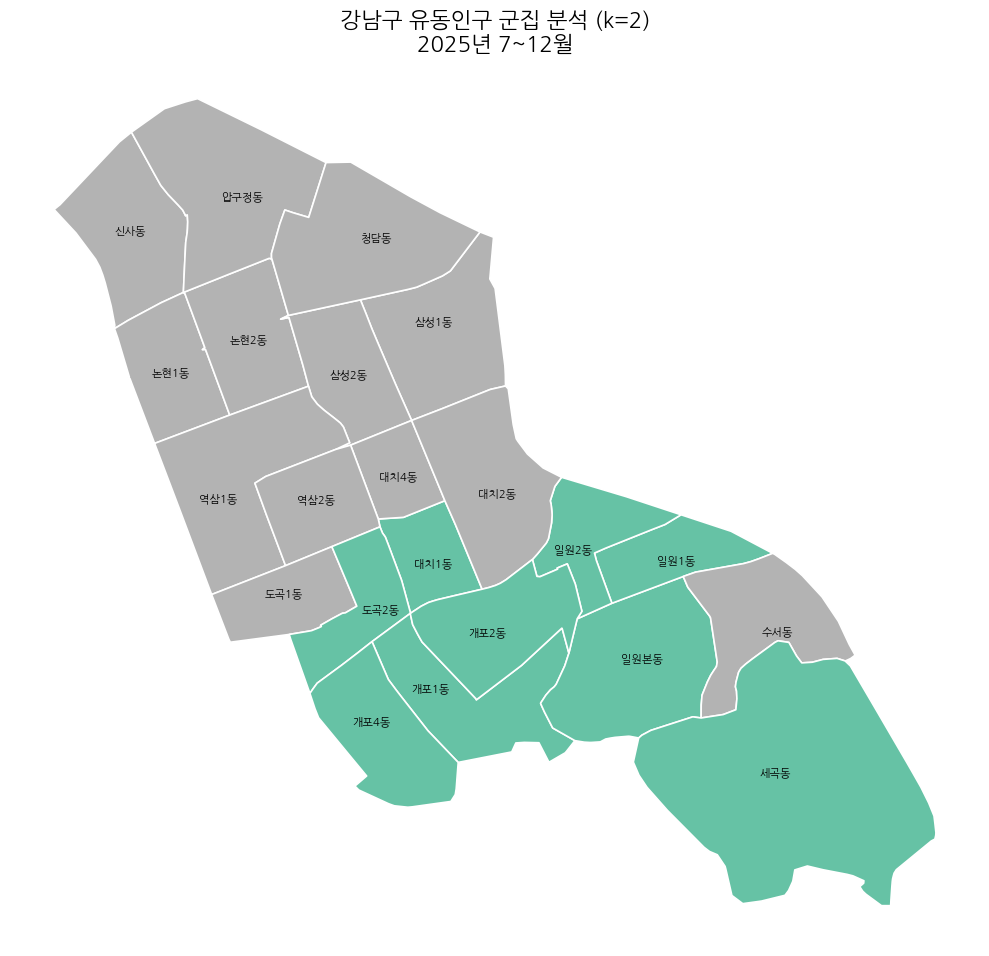

In [120]:
# --------------------------------------------------
# 4. k=2 군집 지도
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 10)
)

gangnam_cluster_map.plot(
    column="cluster_k2",
    categorical=True,
    cmap="Set2",
    edgecolor="white",
    linewidth=1.2,
    ax=ax
)

# 행정동 이름 표시
for _, row in gangnam_cluster_map.iterrows():

    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["dong_name"],
        fontsize=8,
        ha="center",
        va="center"
    )

ax.set_title(
    "강남구 유동인구 군집 분석 (k=2)\n2025년 7~12월",
    fontsize=16
)

ax.axis("off")

plt.tight_layout()
plt.show()

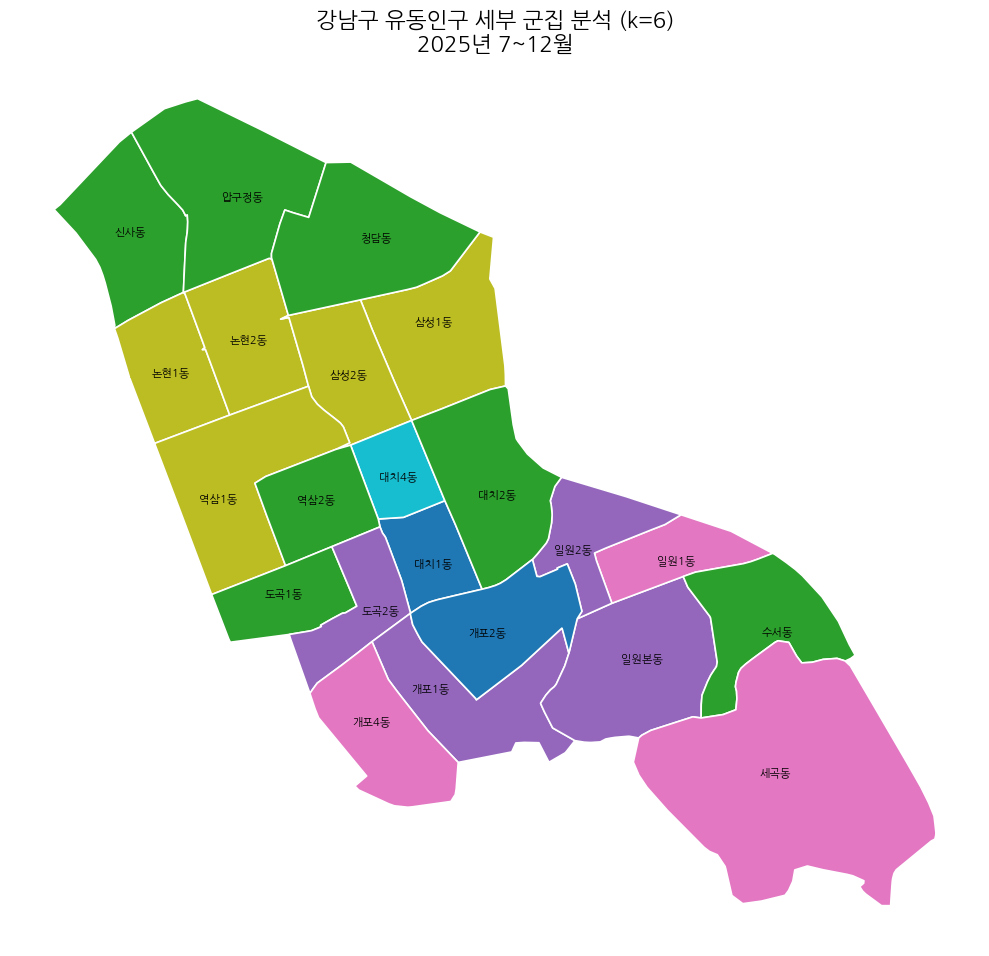

In [121]:
# --------------------------------------------------
# 5. k=6 세부 군집 지도
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 10)
)

gangnam_cluster_map.plot(
    column="cluster_k6",
    categorical=True,
    cmap="tab10",
    edgecolor="white",
    linewidth=1.2,
    ax=ax
)

for _, row in gangnam_cluster_map.iterrows():

    point = row.geometry.representative_point()

    ax.text(
        point.x,
        point.y,
        row["dong_name"],
        fontsize=8,
        ha="center",
        va="center"
    )

ax.set_title(
    "강남구 유동인구 세부 군집 분석 (k=6)\n2025년 7~12월",
    fontsize=16
)

ax.axis("off")

plt.tight_layout()
plt.show()

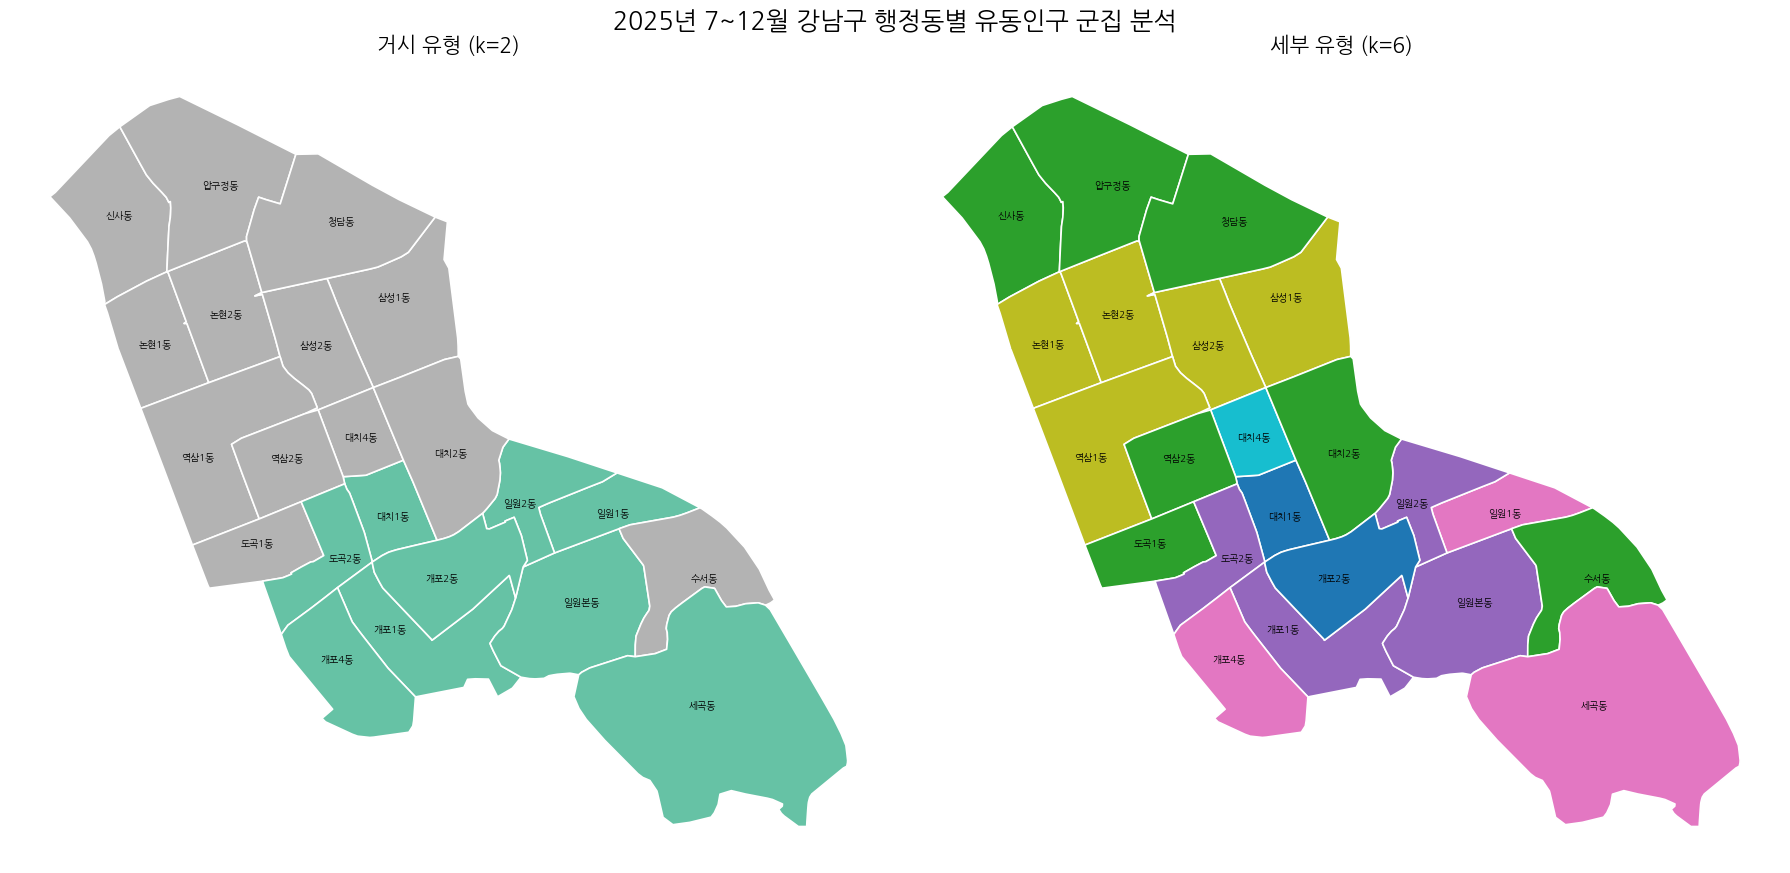

In [122]:
# --------------------------------------------------
# 6. k=2 / k=6 비교 지도
# --------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 9)
)

# --------------------
# k=2
# --------------------

gangnam_cluster_map.plot(
    column="cluster_k2",
    categorical=True,
    cmap="Set2",
    edgecolor="white",
    linewidth=1.2,
    ax=axes[0]
)

for _, row in gangnam_cluster_map.iterrows():

    point = row.geometry.representative_point()

    axes[0].text(
        point.x,
        point.y,
        row["dong_name"],
        fontsize=7,
        ha="center",
        va="center"
    )

axes[0].set_title(
    "거시 유형 (k=2)",
    fontsize=15
)

axes[0].axis("off")


# --------------------
# k=6
# --------------------

gangnam_cluster_map.plot(
    column="cluster_k6",
    categorical=True,
    cmap="tab10",
    edgecolor="white",
    linewidth=1.2,
    ax=axes[1]
)

for _, row in gangnam_cluster_map.iterrows():

    point = row.geometry.representative_point()

    axes[1].text(
        point.x,
        point.y,
        row["dong_name"],
        fontsize=7,
        ha="center",
        va="center"
    )

axes[1].set_title(
    "세부 유형 (k=6)",
    fontsize=15
)

axes[1].axis("off")


# 전체 제목
fig.suptitle(
    "2025년 7~12월 강남구 행정동별 유동인구 군집 분석",
    fontsize=18,
    y=0.98
)

plt.tight_layout()
plt.show()

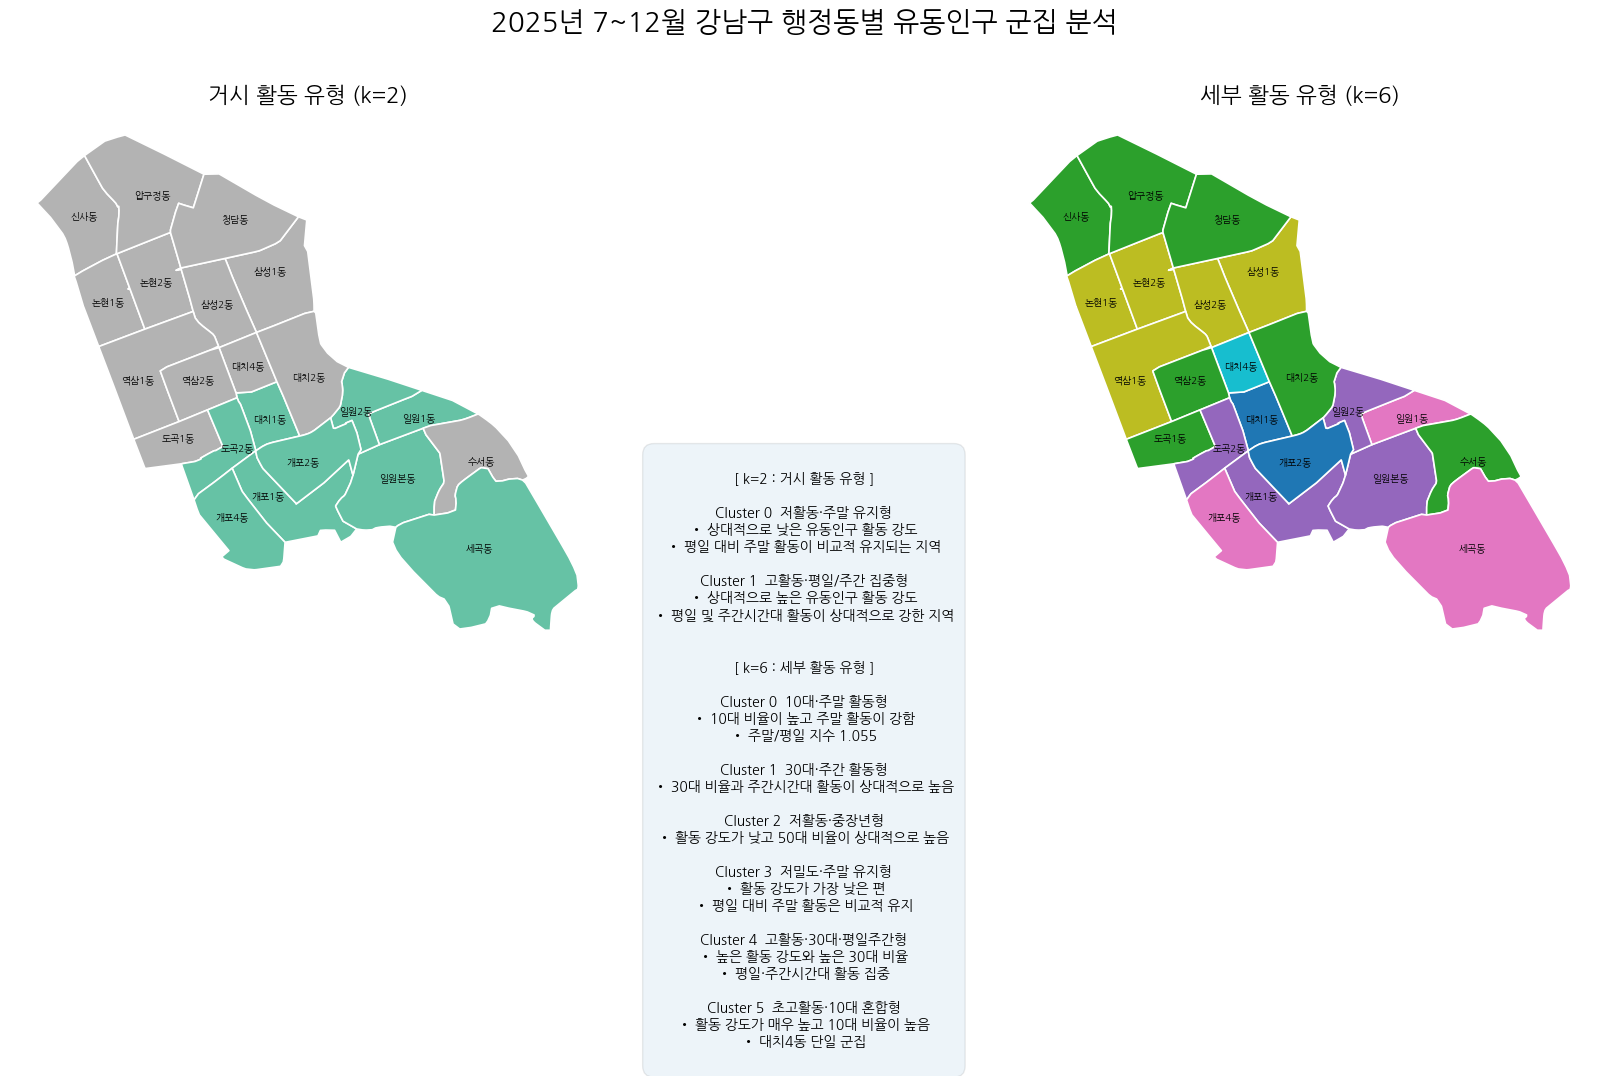

In [123]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --------------------------------------------------
# 군집 설명
# --------------------------------------------------

k2_labels = {
    0: "저활동·주말 유지형",
    1: "고활동·평일/주간 집중형"
}

k6_labels = {
    0: "10대·주말 활동형",
    1: "30대·주간 활동형",
    2: "저활동·중장년형",
    3: "저밀도·주말 유지형",
    4: "고활동·30대·평일주간형",
    5: "초고활동·10대 혼합형"
}


# --------------------------------------------------
# 지도 생성
# --------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 11)
)


# ==================================================
# k = 2 지도
# ==================================================

gangnam_cluster_map.plot(
    column="cluster_k2",
    categorical=True,
    cmap="Set2",
    edgecolor="white",
    linewidth=1.2,
    ax=axes[0]
)

# 행정동 이름
for _, row in gangnam_cluster_map.iterrows():

    point = row.geometry.representative_point()

    axes[0].text(
        point.x,
        point.y,
        row["dong_name"],
        fontsize=7,
        ha="center",
        va="center"
    )

axes[0].set_title(
    "거시 활동 유형 (k=2)",
    fontsize=16,
    fontweight="bold"
)

axes[0].axis("off")


# ==================================================
# k = 6 지도
# ==================================================

gangnam_cluster_map.plot(
    column="cluster_k6",
    categorical=True,
    cmap="tab10",
    edgecolor="white",
    linewidth=1.2,
    ax=axes[1]
)

# 행정동 이름
for _, row in gangnam_cluster_map.iterrows():

    point = row.geometry.representative_point()

    axes[1].text(
        point.x,
        point.y,
        row["dong_name"],
        fontsize=7,
        ha="center",
        va="center"
    )

axes[1].set_title(
    "세부 활동 유형 (k=6)",
    fontsize=16,
    fontweight="bold"
)

axes[1].axis("off")


# ==================================================
# 전체 제목
# ==================================================

fig.suptitle(
    "2025년 7~12월 강남구 행정동별 유동인구 군집 분석",
    fontsize=20,
    fontweight="bold",
    y=0.98
)


# ==================================================
# 군집 설명
# ==================================================

description = """
[ k=2 : 거시 활동 유형 ]

Cluster 0  저활동·주말 유지형
• 상대적으로 낮은 유동인구 활동 강도
• 평일 대비 주말 활동이 비교적 유지되는 지역

Cluster 1  고활동·평일/주간 집중형
• 상대적으로 높은 유동인구 활동 강도
• 평일 및 주간시간대 활동이 상대적으로 강한 지역


[ k=6 : 세부 활동 유형 ]

Cluster 0  10대·주말 활동형
• 10대 비율이 높고 주말 활동이 강함
• 주말/평일 지수 1.055

Cluster 1  30대·주간 활동형
• 30대 비율과 주간시간대 활동이 상대적으로 높음

Cluster 2  저활동·중장년형
• 활동 강도가 낮고 50대 비율이 상대적으로 높음

Cluster 3  저밀도·주말 유지형
• 활동 강도가 가장 낮은 편
• 평일 대비 주말 활동은 비교적 유지

Cluster 4  고활동·30대·평일주간형
• 높은 활동 강도와 높은 30대 비율
• 평일·주간시간대 활동 집중

Cluster 5  초고활동·10대 혼합형
• 활동 강도가 매우 높고 10대 비율이 높음
• 대치4동 단일 군집
"""


fig.text(
    0.5,
    0.02,
    description,
    ha="center",
    va="bottom",
    fontsize=10,
    linespacing=1.4,
    bbox=dict(
        boxstyle="round,pad=0.8",
        alpha=0.08
    )
)


# 지도와 설명 사이 공간 확보
plt.tight_layout(
    rect=[0, 0.38, 1, 0.94]
)

plt.show()

In [124]:
from google.colab import files

output_file = "gangnam_db1_features_202507_202512.csv"

gangnam_panel.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>